<a href="https://colab.research.google.com/github/EkaterinaAraud/project/blob/main/%D0%92%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D1%8B%D0%B5_%D1%80%D1%8F%D0%B4%D1%8B_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span></li><li><span><a href="#Анализ" data-toc-modified-id="Анализ-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Анализ</a></span></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Обучение</a></span></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Тестирование</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

#  Прогнозирование потребления электроэнергии


Имеются данные о потреблении электроэнергии. Чтобы прогнозировать нагрузку электросетей, построим модель для такого предсказания.

Необходимо:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.

Набор данных был сохранен в формате txt с использованием формата csv и разделителя-точки с запятой (;).
 В первом столбце дата и время представлены в виде строки в следующем формате: 'гггг-мм-дд чч:мм:сс'
 В остальных столбцах представлены значения с плавающей запятой, отражающие потребление в кВт для отдельных потребителей.



В наборе данных представлено 370 потребителей. Соответственно нам необходимо выбрать стратегию прогнозирования.  


**1. Суммарное потребление (агрегированный подход)**

Что это: сначала суммируем потребление всех потребителей по временным интервалам, затем строим модель на суммарном ряде.

**Плюсы:**

- проще моделировать один ряд вместо сотен;

- сглаживаются индивидуальные аномалии потребителей;

- меньше шума в данных;

- быстрее обучение и inference;

- подходит для задач планирования генерации/закупки энергии.

**Минусы:**

- теряются индивидуальные паттерны потребителей;

- нельзя получить прогноз по отдельным потребителям;

- могут маскироваться локальные пики отдельных потребителей.

**2. Отдельные модели для каждого потребителя**

Что это: для каждого столбца (потребителя) создаётся своя модель.

**Плюсы:**

- учёт индивидуальных особенностей каждого потребителя;

- высокая точность для ключевых потребителей;

- возможность анализировать аномалии на уровне потребителя.

**Минусы:**

- ресурсоёмкость: сотни моделей требуют много памяти и времени;

- сложно поддерживать и обновлять;

- для мелких потребителей может быть избыточно.

**3. Групповой подход (кластеризация + моделирование)**

Что это:Кластеризуем потребителей по схожести паттернов потребления.

Для каждого кластера строим отдельную модель.


**Плюсы:**
- баланс между детализацией и эффективностью; учёт схожих паттернов.

**Минусы:**
- требует этапа кластеризации; выбор числа кластеров неочевиден.

**4. Многомерная модель (multivariate)**

Что это: модель, которая одновременно учитывает данные всех потребителей как признаки.

Подходящие модели: LSTM, GRU, Transformer.

**Плюсы:**
- учёт взаимосвязей между потребителями; потенциально высокая точность.

**Минусы:**
- сложность настройки; высокие требования к данным и вычислительным ресурсам; риск переобучения.

**5. Иерархическое прогнозирование**

Что это: комбинируете уровни:

верхний уровень — суммарное потребление;

нижний уровень — отдельные потребители или группы.

согласовываем прогнозы между уровнями.

**Плюсы:**
- согласованность прогнозов на разных уровнях; гибкость.

**Минусы:**
- высокая сложность реализации; требует специальных методов согласования.


В нашем случае начнем с простого:

Базовый вариант — прогнозирование суммарного потребления. Это даст нам:

базовый уровень качества (baseline);

понимание общей динамики системы;

отправную точку для сравнения с более сложными подходами.

Анализ потребителей:

выделим топ‑10–20 потребителей, которые дают 80–90 % потребления;

для них построим отдельные модели;

остальных объединим в группу «прочие» и прогнозируем суммарно.




## Подготовка

Импортируем необходимые библиотеки.

In [ ]:
!pip install -Uq scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 43.1 MB/s eta 0:00:00


In [ ]:
!pip install phik -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 11.7 MB/s eta 0:00:00


In [ ]:
pip install lightgbm -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression, ElasticNet
import lightgbm as lgbm
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_squared_error

from phik.report import correlation_report, plot_correlation_matrix


import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Загрузим данные для анализа и прогнозирования. Вначале посмотрим на содержание файла.

In [ ]:
with open('/content/sample_data/LD2011_2014.txt', 'r', encoding='utf-8') as f:
    all_lines = f.readlines()

# Первые 5 строк
print("Первые 5 строк:")
for i in range(min(5, len(all_lines))):  # защита от файлов меньше 5 строк
    print(f"Строка {i+1}: {all_lines[i].strip()}")

# Последние 5 строк
print("\nПоследние 5 строк:")
start_idx = max(0, len(all_lines) - 5)  # если строк <5, берём с начала
for i in range(start_idx, len(all_lines)):
    line_num = i + 1
    print(f"Строка {line_num}: {all_lines[i].strip()}")



Первые 5 строк:
Строка 1: "";"MT_001";"MT_002";"MT_003";"MT_004";"MT_005";"MT_006";"MT_007";"MT_008";"MT_009";"MT_010";"MT_011";"MT_012";"MT_013";"MT_014";"MT_015";"MT_016";"MT_017";"MT_018";"MT_019";"MT_020";"MT_021";"MT_022";"MT_023";"MT_024";"MT_025";"MT_026";"MT_027";"MT_028";"MT_029";"MT_030";"MT_031";"MT_032";"MT_033";"MT_034";"MT_035";"MT_036";"MT_037";"MT_038";"MT_039";"MT_040";"MT_041";"MT_042";"MT_043";"MT_044";"MT_045";"MT_046";"MT_047";"MT_048";"MT_049";"MT_050";"MT_051";"MT_052";"MT_053";"MT_054";"MT_055";"MT_056";"MT_057";"MT_058";"MT_059";"MT_060";"MT_061";"MT_062";"MT_063";"MT_064";"MT_065";"MT_066";"MT_067";"MT_068";"MT_069";"MT_070";"MT_071";"MT_072";"MT_073";"MT_074";"MT_075";"MT_076";"MT_077";"MT_078";"MT_079";"MT_080";"MT_081";"MT_082";"MT_083";"MT_084";"MT_085";"MT_086";"MT_087";"MT_088";"MT_089";"MT_090";"MT_091";"MT_092";"MT_093";"MT_094";"MT_095";"MT_096";"MT_097";"MT_098";"MT_099";"MT_100";"MT_101";"MT_102";"MT_103";"MT_104";"MT_105";"MT_106";"MT_107";"MT_108"

При загрузке данных предусмотрим парсинг дат и замену запятых на точки, преобразованием в формат float.


In [ ]:
data = pd.read_csv(
    '/content/sample_data/LD2011_2014.txt',
    sep=';',
    decimal=',',
    thousands=None,
    header=0,
    index_col=0,
    parse_dates=True,

)

# Преобразование всех столбцов (кроме индекса) в тип float
data = data.astype(float)


# Проверка результата
print(data.head())
print("\nТипы данных:")
print(data.dtypes)
print("\nИнформация о DataFrame:")
print(data.info())


                     MT_001  MT_002  MT_003  MT_004  MT_005  MT_006  MT_007  \
2011-01-01 00:15:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2011-01-01 00:30:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2011-01-01 00:45:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2011-01-01 01:00:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2011-01-01 01:15:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

                     MT_008  MT_009  MT_010  ...  MT_361  MT_362  MT_363  \
2011-01-01 00:15:00     0.0     0.0     0.0  ...     0.0     0.0     0.0   
2011-01-01 00:30:00     0.0     0.0     0.0  ...     0.0     0.0     0.0   
2011-01-01 00:45:00     0.0     0.0     0.0  ...     0.0     0.0     0.0   
2011-01-01 01:00:00     0.0     0.0     0.0  ...     0.0     0.0     0.0   
2011-01-01 01:15:00     0.0     0.0     0.0  ...     0.0     0.0     0.0   

                     MT_364  MT_365  MT_366  MT_367  MT_368  MT_369 

Выведем первые пять строк для понимания структуры данных.

In [ ]:
data.head()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
data.tail()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2012-01-25 08:00:00,3.807107,34.850640,77.324066,93.495935,51.219512,220.238095,2.826456,212.121212,66.433566,44.086022,...,114.204140,15700.0,877.637131,1568.181818,16.949153,26.331188,431.079895,131.886477,767.595308,0.0
2012-01-25 08:15:00,1.269036,34.139403,77.324066,95.528455,45.121951,220.238095,2.261164,269.360269,113.636364,43.010753,...,112.776588,15900.0,966.244726,1590.909091,18.252934,24.575775,399.473222,130.217028,782.991202,0.0
2012-01-25 08:30:00,1.269036,32.716927,76.455256,117.886179,46.341463,217.261905,3.391747,249.158249,111.888112,44.086022,...,114.917916,17900.0,974.683544,1568.181818,19.556714,5.851375,413.520632,136.894825,773.460411,0.0
2012-01-25 08:45:00,1.269036,28.449502,78.192876,109.756098,42.682927,217.261905,2.261164,276.094276,117.132867,44.086022,...,137.758744,18600.0,1025.316456,1727.272727,56.062581,7.606788,421.422300,146.911519,805.718475,0.0
2012-01-25 09:00:00,2.538071,28.449502,78.192876,99.593496,42.682927,223.214286,2.261164,272.727273,111.888112,38.709677,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data.columns

Index(['MT_001', 'MT_002', 'MT_003', 'MT_004', 'MT_005', 'MT_006', 'MT_007',
       'MT_008', 'MT_009', 'MT_010',
       ...
       'MT_361', 'MT_362', 'MT_363', 'MT_364', 'MT_365', 'MT_366', 'MT_367',
       'MT_368', 'MT_369', 'MT_370'],
      dtype='object', length=370)

In [ ]:
# Получаем сумму пропусков по столбцам
missing_counts = data.isnull().sum()

# Оставляем только столбцы с хотя бы одним пропуском
columns_with_missing = missing_counts[missing_counts > 0]

# Выводим результат
print("Столбцы с пропущенными значениями:")
print(columns_with_missing)


Столбцы с пропущенными значениями:
MT_101    1
MT_102    1
MT_103    1
MT_104    1
MT_105    1
         ..
MT_366    1
MT_367    1
MT_368    1
MT_369    1
MT_370    1
Length: 270, dtype: int64


Найдем общее потребление.


In [ ]:
data['total_consumption'] = data.sum(axis=1)

# Создаём новый DataFrame только с датой/временем и суммарным потреблением
total_consumption_df = data['total_consumption']

print("Датасет с суммарным потреблением создан!")
print(f"Размер датасета: {total_consumption_df.shape}")
print("\nПервые 10 строк:")
print(total_consumption_df.head(10))

Датасет с суммарным потреблением создан!
Размер датасета: (44172,)

Первые 10 строк:
2011-01-01 00:15:00    68513.115338
2011-01-01 00:30:00    69180.304361
2011-01-01 00:45:00    69364.850573
2011-01-01 01:00:00    68350.480660
2011-01-01 01:15:00    66166.874303
2011-01-01 01:30:00    64843.191940
2011-01-01 01:45:00    66017.963844
2011-01-01 02:00:00    65345.513794
2011-01-01 02:15:00    65567.578171
2011-01-01 02:30:00    65765.802247
Name: total_consumption, dtype: float64


Обработка аномалий из‑за перехода на летнее/зимнее время


Алгоритм:
- Найти даты перехода на летнее и зимнее время.
- Для зимнего времени: установить нулевые значения в интервале 01:00–02:00.
- Для летнего времени: разделить удвоенные значения в интервале 01:00–02:00 пополам.


In [ ]:
# Проверка типа индекса
print("Тип индекса:", type(total_consumption_df.index))

# Если индекс не DatetimeIndex, преобразуем
if not isinstance(total_consumption_df.index, pd.DatetimeIndex):
    total_consumption_df.index = pd.to_datetime(total_consumption_df.index)
    print("Индекс преобразован в DatetimeIndex")


Тип индекса: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [ ]:
total_consumption_df

,total_consumption
2011-01-01 00:15:00,68513.115338
2011-01-01 00:30:00,69180.304361
2011-01-01 00:45:00,69364.850573
2011-01-01 01:00:00,68350.480660
2011-01-01 01:15:00,66166.874303
...,...
2012-04-05 02:00:00,108853.569353
2012-04-05 02:15:00,107799.890335
2012-04-05 02:30:00,107956.858690
2012-04-05 02:45:00,105136.210123


In [ ]:
def fix_dst_anomalies(df):
    """
    Исправляет аномалии в данных из‑за перехода на летнее/зимнее время.
    """
    df_fixed = df.copy()
    dates = df_fixed.index.date
    unique_dates = pd.Series(dates).unique()

    for date in unique_dates:
        # Создаём временные метки для периода 01:00–02:00
        start_time = pd.Timestamp(f"{date} 01:00:00")
        end_time = pd.Timestamp(f"{date} 02:00:00")

        # Фильтруем строки в нужном временном интервале
        mask = (df_fixed.index >= start_time) & (df_fixed.index < end_time)
        rows_in_period = df_fixed[mask]

        if len(rows_in_period) == 0:
            continue

        # Проверка количества часов в сутках
        day_data = df_fixed[df_fixed.index.date == date]
        hours_in_day = len(day_data) / 4  # 96 измерений = 24 часа

        if hours_in_day < 24:
            # Зимнее время (23 часа): устанавливаем нули для периода 01:00–02:00
            df_fixed.loc[mask] = 0.0
        elif hours_in_day > 24:
            # Летнее время (25 часов): делим значения пополам для периода 01:00–02:00
            df_fixed.loc[mask] = df_fixed.loc[mask] / 2.0

    return df_fixed

# Применяем исправление
data_new = fix_dst_anomalies(total_consumption_df)


In [ ]:
# Первые 10 строк после обработки
print("После исправления:")
print(data_new.head(10))

# Статистика по данным
print("\nСтатистика до исправления:")
print(total_consumption_df.describe())
print("\nСтатистика после исправления:")
print(data_new.describe())


После исправления:
2011-01-01 00:15:00    68513.115338
2011-01-01 00:30:00    69180.304361
2011-01-01 00:45:00    69364.850573
2011-01-01 01:00:00        0.000000
2011-01-01 01:15:00        0.000000
2011-01-01 01:30:00        0.000000
2011-01-01 01:45:00        0.000000
2011-01-01 02:00:00    65345.513794
2011-01-01 02:15:00    65567.578171
2011-01-01 02:30:00    65765.802247
Name: total_consumption, dtype: float64

Статистика до исправления:
count     44172.000000
mean     135633.129803
std       46723.145475
min        4081.815779
25%      101432.541010
50%      136124.308920
75%      157142.022546
max      277002.996250
Name: total_consumption, dtype: float64

Статистика после исправления:
count     44172.000000
mean     135617.047972
std       46753.550923
min           0.000000
25%      101427.157869
50%      136124.308920
75%      157142.022546
max      277002.996250
Name: total_consumption, dtype: float64


## Анализ данных


Клиенты, добавленные после 2011 года, имеют нулевые значения до момента подключения. Оставим нули — это корректно отражает отсутствие потребления.

Убедимся, что в каждом дне ровно 96 измерений (24 × 4)

In [ ]:
def check_daily_measurements(df):
    daily_counts = df.resample('D').size()
    anomalous_days = daily_counts[daily_counts != 96]
    if len(anomalous_days) > 0:
        print("Аномальные дни (не 96 измерений):")
        print(anomalous_days)
    else:
        print("Все дни содержат 96 измерений.")

check_daily_measurements(data_new)


Аномальные дни (не 96 измерений):
2011-01-01    95
2012-04-05    13
Name: total_consumption, dtype: int64


Проверим минимальный и максимальный индекс в данных.

In [ ]:
min_date = data_new.index.min()
max_date = data_new.index.max()


print(f"Минимальная дата: {min_date}")
print(f"Максимальная дата: {max_date}")


Минимальная дата: 2011-01-01 00:15:00
Максимальная дата: 2012-04-05 03:00:00


Аномальные дня совпадают с первым и последним днем в наблюдениях. Это может только означать, что измерение начали делать не с самого начала дня, и последнее измерение сделано один раз в начале суток. Поэтому эти дни можно отбросить, так как далее планируется сделать ресемплинг по часу.


Изучим данные вокруг проблемных периодов:

In [ ]:
# Получаем минимальную и максимальную дату (только дата, без времени)
min_date_day = data_new.index.normalize().min().date()
max_date_day = data_new.index.normalize().max().date()


# Создаём маску: оставляем только строки, где дата НЕ равна минимальной и НЕ равна максимальной
mask = ~((data_new.index.date == min_date_day) |
           (data_new.index.date == max_date_day))


data_filtered = data_new[mask]

# Выводим статистику
print(f"Исходный размер: {len(data_new)}")
print(f"Размер после фильтрации: {len(data_filtered)}")
print(f"Удалено строк: {len(data_new) - len(data_filtered)}")
print(f"Удалены дни: {min_date_day} и {max_date_day}")

Исходный размер: 44172
Размер после фильтрации: 44064
Удалено строк: 108
Удалены дни: 2011-01-01 и 2012-04-05


In [ ]:
data_filtered.sort_index(inplace=True)

Произведем ресемплирование данных по часу. Будем делать прогнозы для интервала в час. Для каждого часа посчитаем суммарное количество потребляемой электроэнергии.

In [ ]:
data_filtered = data_filtered.resample('1H').sum()

In [ ]:
data_filtered.head()

,total_consumption
2011-01-02 00:00:00,275620.389448
2011-01-02 01:00:00,262831.978574
2011-01-02 02:00:00,260747.184150
2011-01-02 03:00:00,260955.794743
2011-01-02 04:00:00,264759.088955


Изучим распределение целевой переменной.

In [ ]:
pd.options.display.float_format = '{:,.0f}'.format

In [ ]:
data_filtered.describe()

,total_consumption
count,"11,016"
mean,"543,111"
std,"185,890"
min,"17,148"
25%,"405,630"
50%,"545,150"
75%,"628,120"
max,"1,067,355"


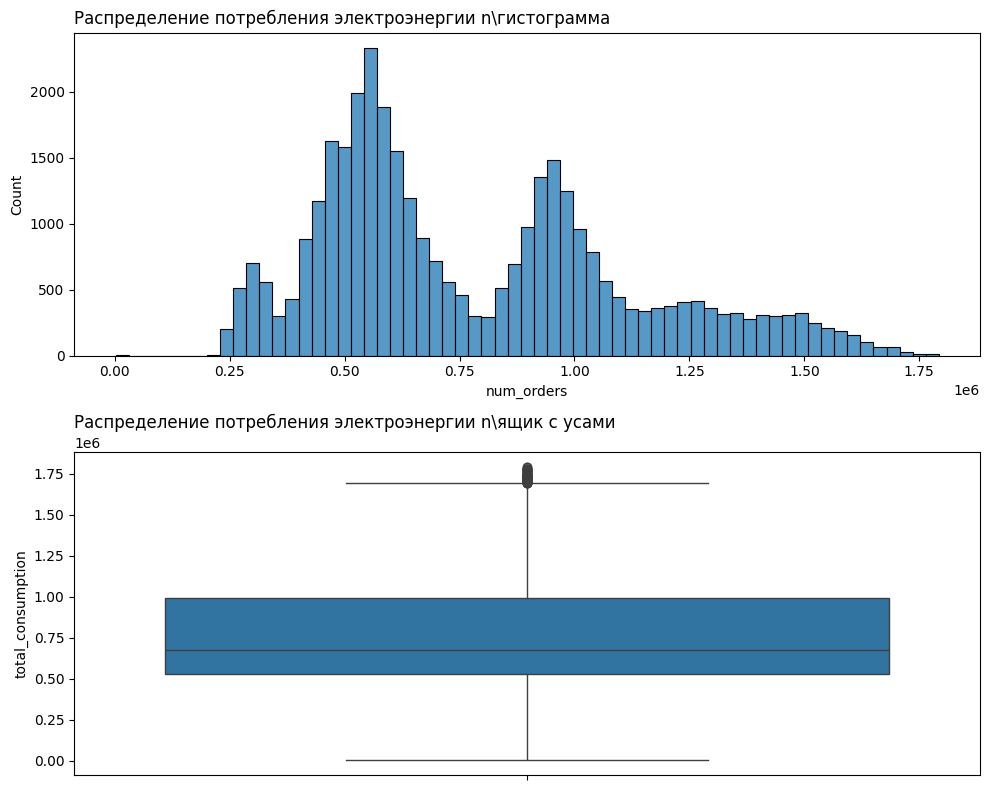

In [ ]:
plt.figure(figsize=(10, 8))
plt.subplot(211)
sns.histplot(data=data_filtered)
plt.xlabel('num_orders')
plt.title('Распределение потребления электроэнергии n\гистограмма', loc='left')
plt.subplot(212)
sns.boxplot(data=data_filtered)
plt.title('Распределение потребления электроэнергии n\ящик с усами', loc='left')
plt.tight_layout()

**Промежуточный вывод**

Импортировали необходимые билиотеки для проекта. Загрузили данные, при загрузке сразу же указали дату как индекс датафрейм и использовали parse_dates. Отсортировали данные в хронологическом порядке, произвели ресемплирование по часу с подсчетом суммарного количества потребленной электроэнергии. Изучили распределение целевой переменной. Увидели по графикам, что распределение многомодальное. Скорее всего это связано с тредном внутри суток. Также присутствуют аномально низкие значения, что скорее всего связано с особенностями данных при переходе на зимнее время. Есть и аномально большие значения. Мы не будем это считать аномалиями, так как действительно есть периоды в сутках, когда энергия не используется, а есть наоборот редкие пики (например, перед праздниками, когда люди много готовят). В любом случае мы не будем делать никаких манипуляций с целевой переменной.

Проверим за какой промежуток времени мы имеем данные.

In [ ]:
print('Начало периода: ', data_filtered.index[0], '      ', 'Конец периода: ', data_filtered.index[-1])

Начало периода:  2011-01-02 00:00:00        Конец периода:  2012-04-04 23:00:00


Итого имеем данные за период с 2 января 2011 года по 31 декабря 2014 года. Это позволит нам понять тренд и сезонность.

Построим график потребления.

In [ ]:
data_filtered.head()

,total_consumption
2011-01-02 00:00:00,"275,620"
2011-01-02 01:00:00,"262,832"
2011-01-02 02:00:00,"260,747"
2011-01-02 03:00:00,"260,956"
2011-01-02 04:00:00,"264,759"


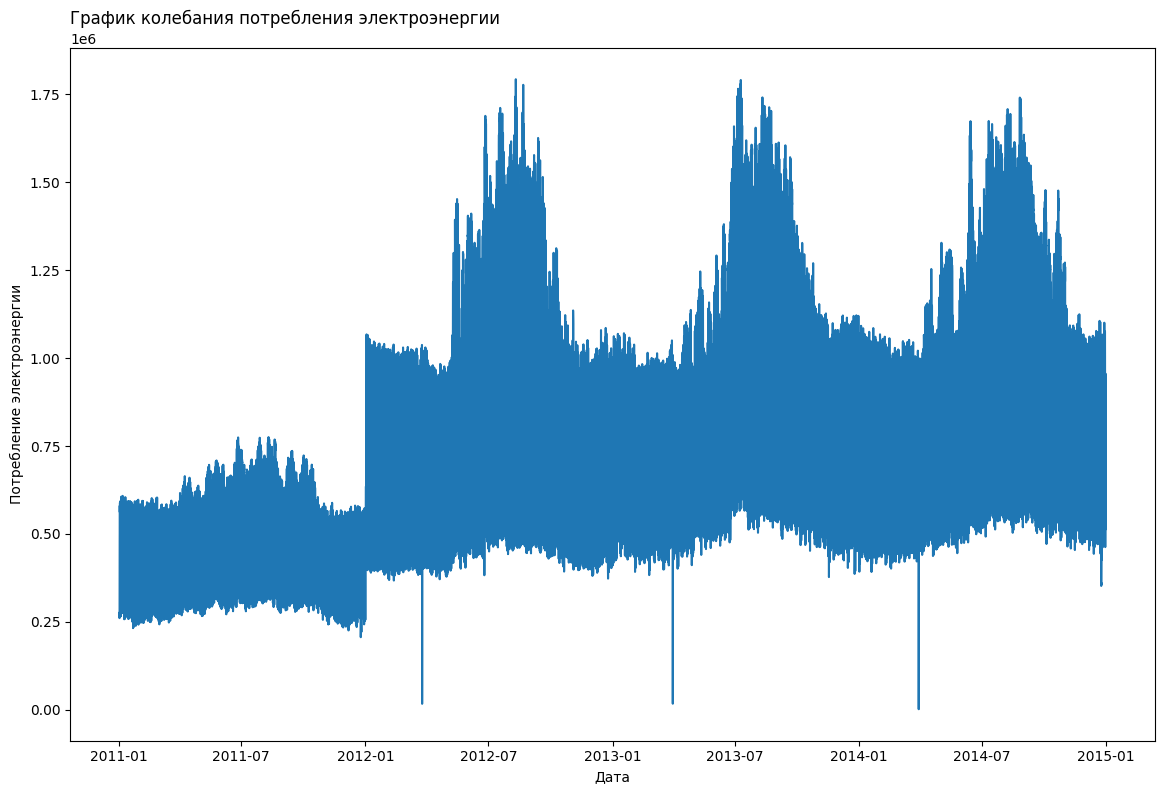

In [ ]:
plt.figure(figsize=(14, 9))
sns.lineplot(x=data_filtered.index, y=data_filtered.values)
plt.title('График колебания потребления электроэнергии', loc='left')
plt.xlabel('Дата')
plt.ylabel('Потребление электроэнергии')
plt.show()

На графике заметно, что тренд пошел на резкий рост. Это связано с тем, что в данных присутствуют потребители, которые подключились позже 2011 года. Поэтому отбросим полностью 2011 год, чтобы не вносить шум в модель. Также видим постоянные колебания. В таком виде график не информативен. Добавим в данные скользящее среднее. Сделаем окна:
- 24 часа (чтобы понять недельный тренд)
- 12 часов (чтобы понять тренд ночь-день)
- 8 часов (чтобы понять тренд ночь-утро-вечер)

И далее построим графики.

In [ ]:
data_without_2011 = data_filtered[data_filtered.index.year != 2011]

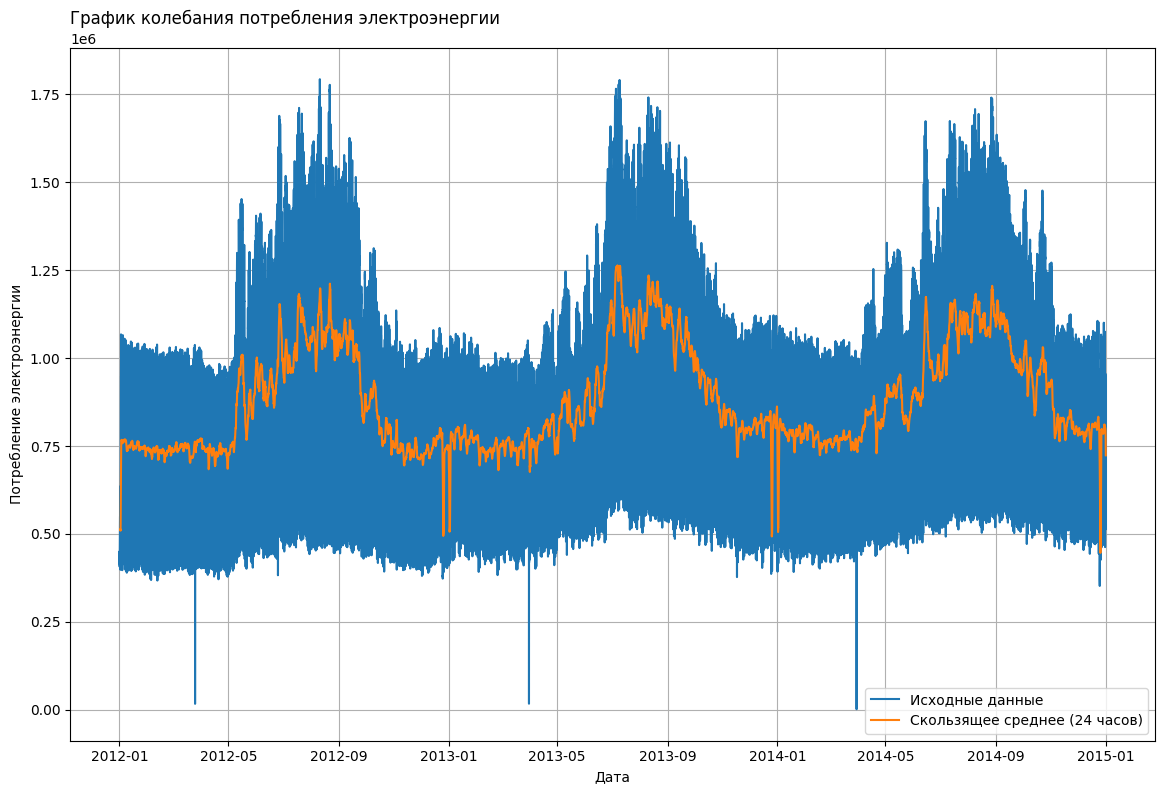

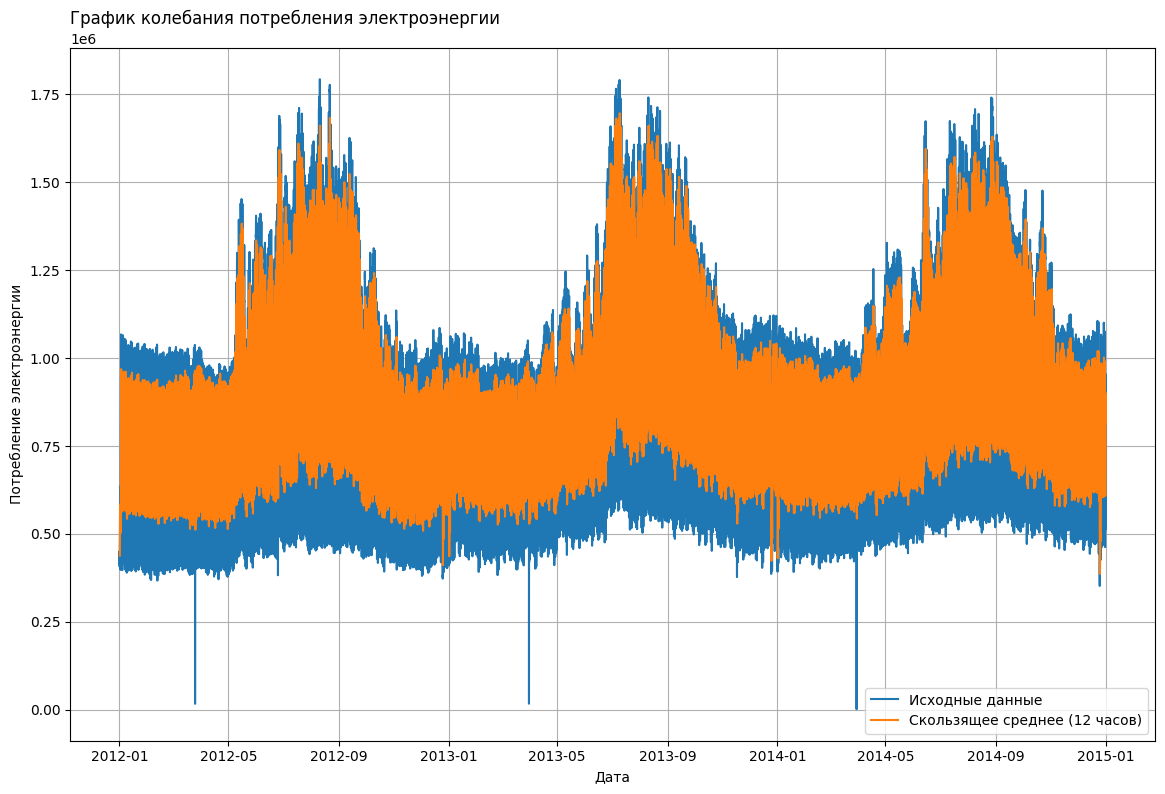

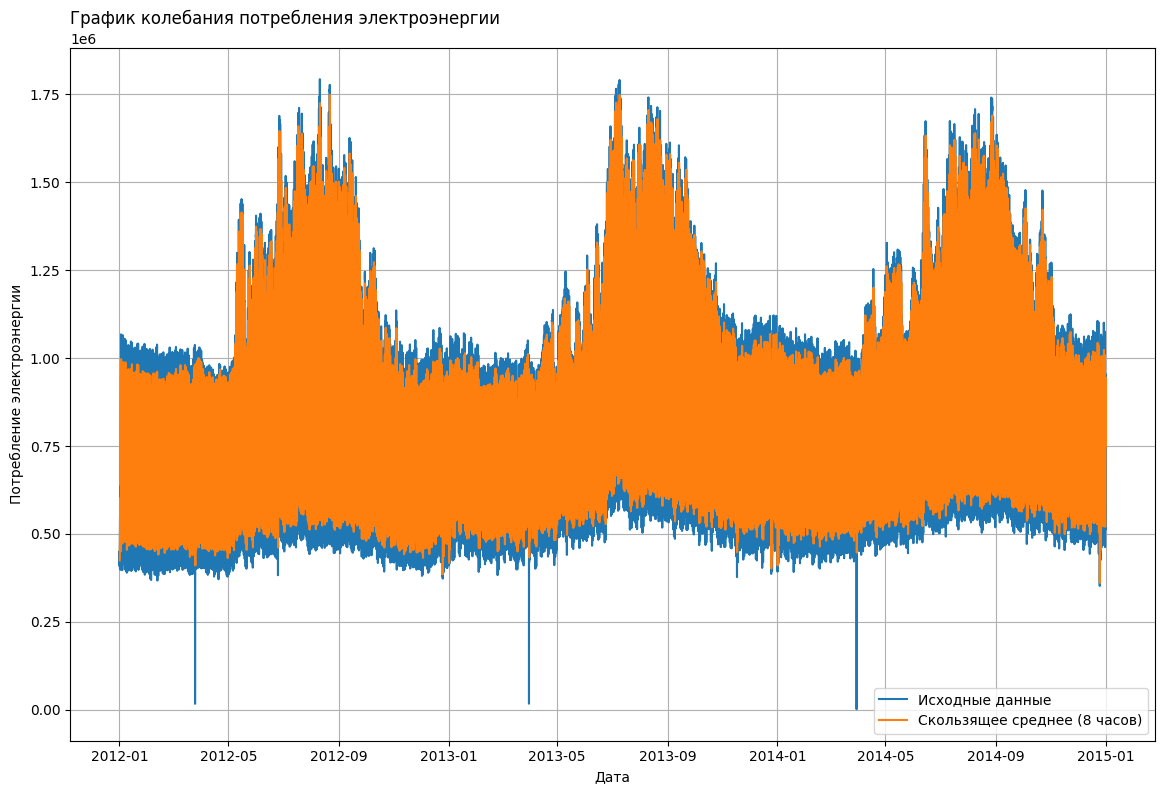

In [ ]:
for i in [24, 12, 8]:
    plt.figure(figsize=(14, 9))

    # Строим исходный ряд (без параметра data)
    sns.lineplot(x=data_without_2011.index, y=data_without_2011.values, label='Исходные данные')

    # Строим скользящее среднее (без параметра data)
    rolling_mean = data_without_2011.rolling(i).mean()
    sns.lineplot(x=rolling_mean.index, y=rolling_mean.values, label=f'Скользящее среднее ({i} часов)')


    plt.title('График колебания потребления электроэнергии', loc='left')
    plt.xlabel('Дата')
    plt.ylabel('Потребление электроэнергии')
    plt.grid(True)
    plt.show()


По графикам делаем вывод, что в целом тренд не меняется и ряд практически стационарен. Но видим, что присутствует сезонность: всплески в мае-сентябре, а затем падение с сентября по конец года.

С помощью библиотеки statsmodels изучим тренд и сезонность.

In [ ]:

# Убедимся, что данные отсортированы по времени
data_without_2011 = data_without_2011.sort_index()


# Выполняем декомпозицию
# Период задаём исходя из частоты данных:
# - если данные почасовые и ищем суточную сезонность: period=24
# - если ищем недельную сезонность: period=168 (24*7)
decomposed = seasonal_decompose(
    data_without_2011,
    model='additive',  # или 'multiplicative'
    period=24  # задайте подходящий период
)


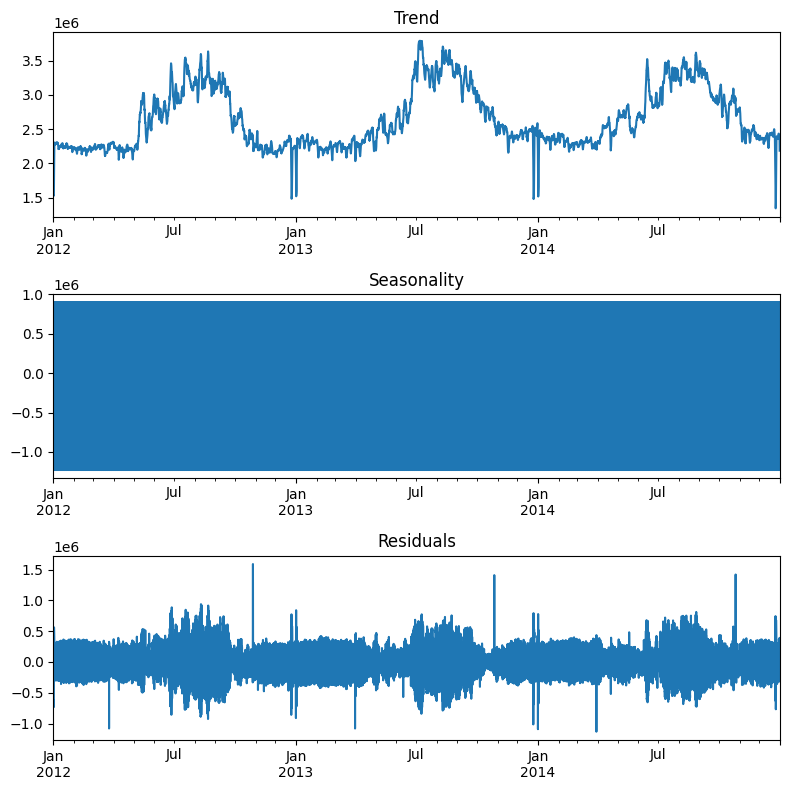

In [ ]:

plt.figure(figsize=(8, 8))
plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Trend')
plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca())
plt.title('Seasonality')
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Residuals')
plt.tight_layout()

Графики подтвердили наши прежние выводы.

Проверим дополнительно внутрисуточную, недельную, месячную и квартальную сезонность сезонность.

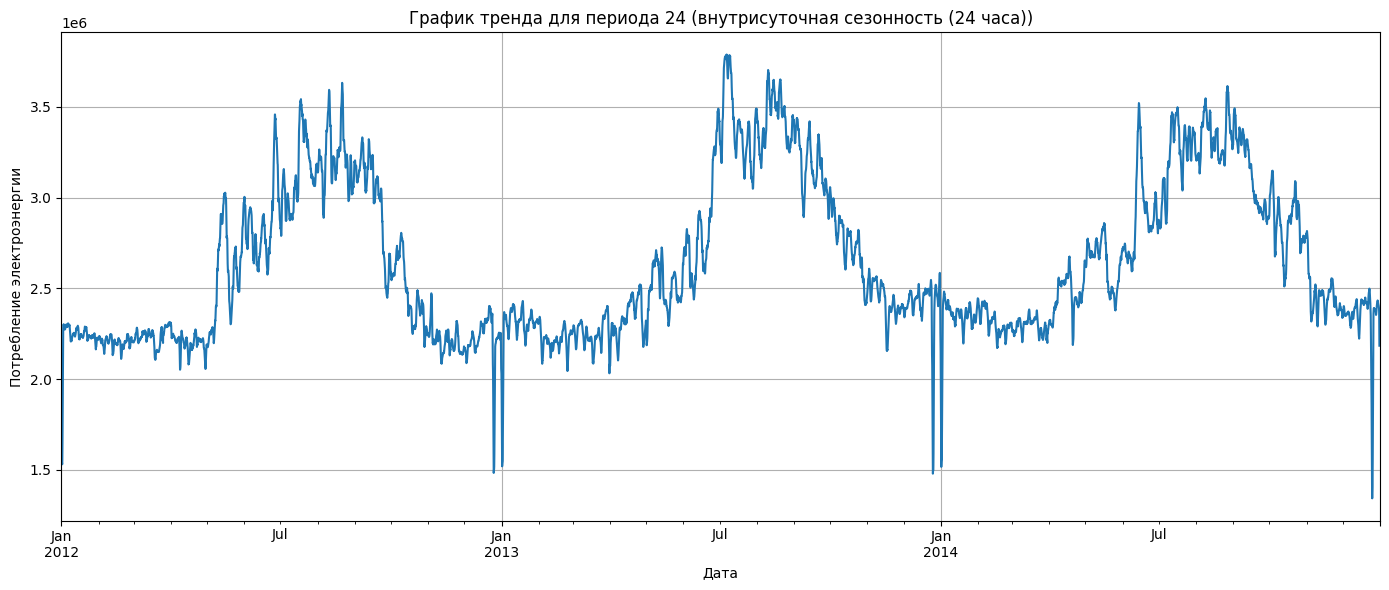

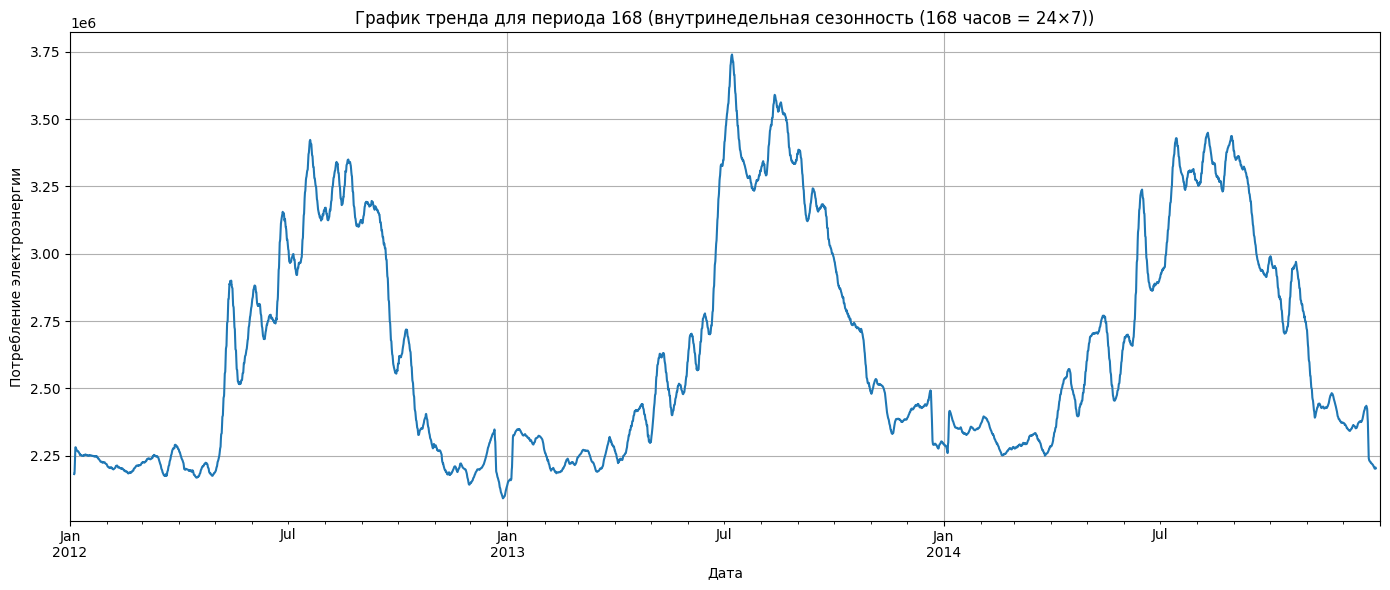

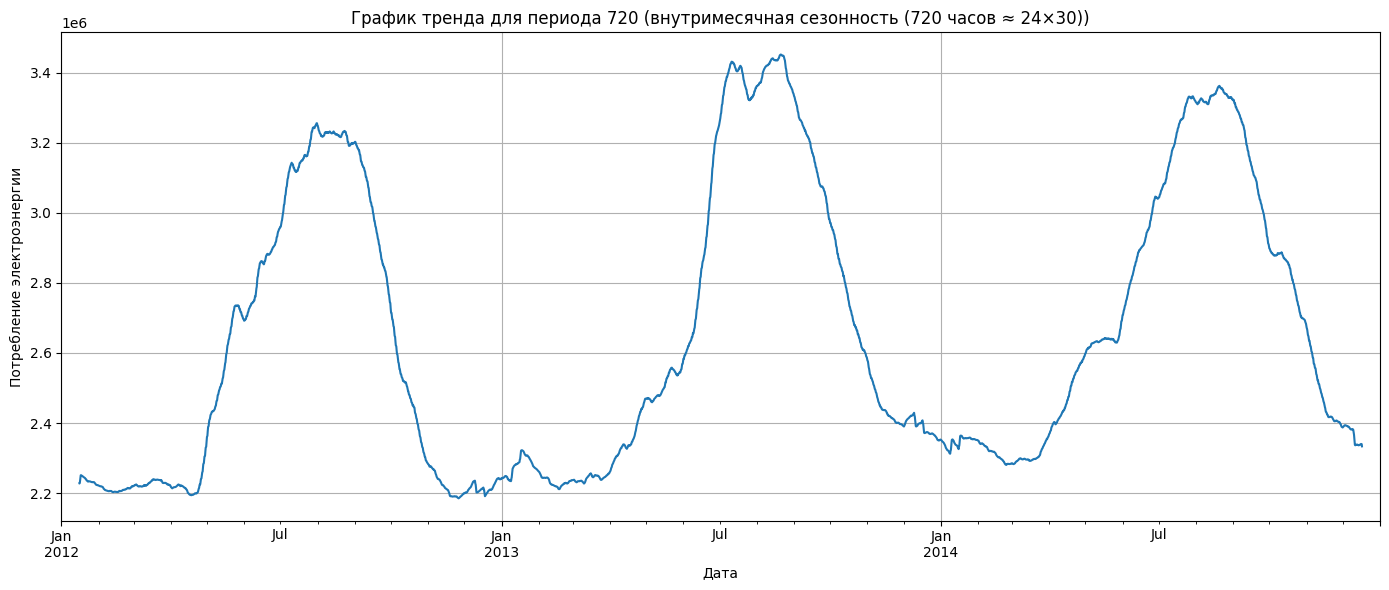

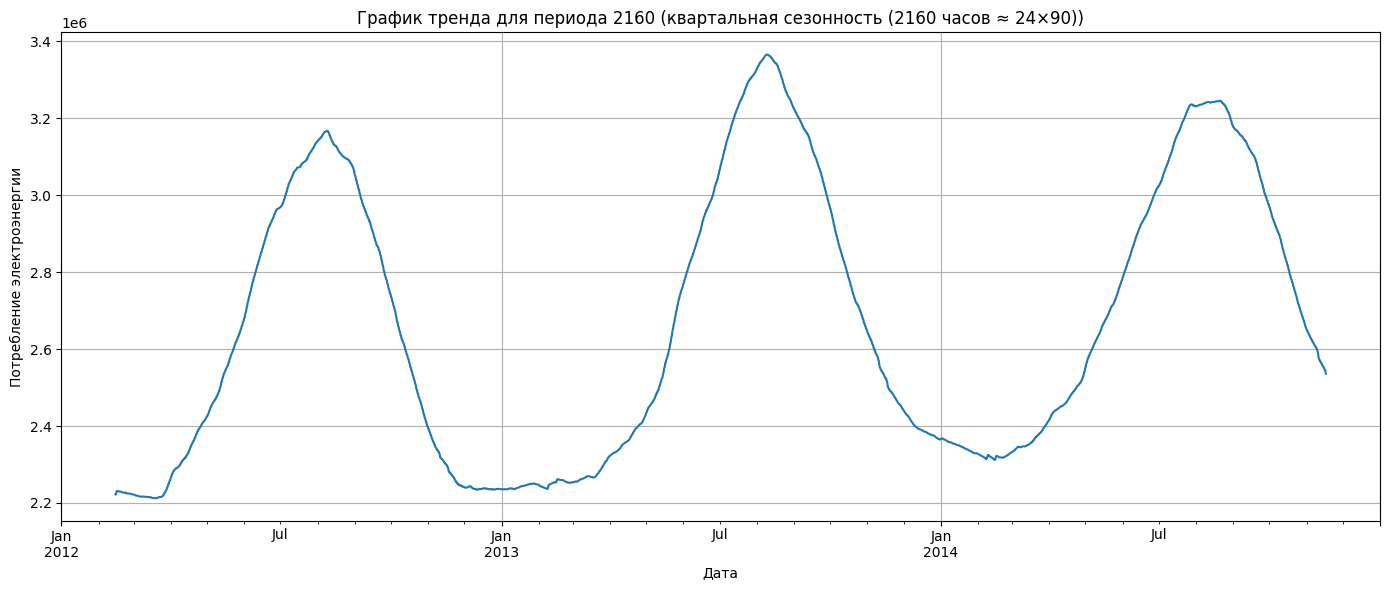

In [ ]:
# Список периодов с пояснениями
periods = [
    (24, 'внутрисуточная сезонность (24 часа)'),
    (168, 'внутринедельная сезонность (168 часов = 24×7)'),
    (720, 'внутримесячная сезонность (720 часов ≈ 24×30)'),
    (2160, 'квартальная сезонность (2160 часов ≈ 24×90)')
]

for period, description in periods:
    try:
        # Выполняем декомпозицию
        result = seasonal_decompose(
            data_without_2011,
            model='additive',  # можно поменять на 'multiplicative' при необходимости
            period=period
        )

        # Создаём график
        plt.figure(figsize=(14, 6))
        result.trend.plot()
        plt.title(f'График тренда для периода {period} ({description})')
        plt.xlabel('Дата')
        plt.ylabel('Потребление электроэнергии')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except ValueError as e:
        print(f"Ошибка для периода {period} ({description}): {e}")
        print("Возможно, период слишком велик относительно длины данных или недостаточно данных для этого периода.\n")


Как видим согласно графиков для декомпозиции с помощью библиотеки statsmodels.tsa.seasonal, сезонность сильно выраженна и стабильна.

Построим график колебаний для случайных суток. Например, для 31 мая 2012 года.

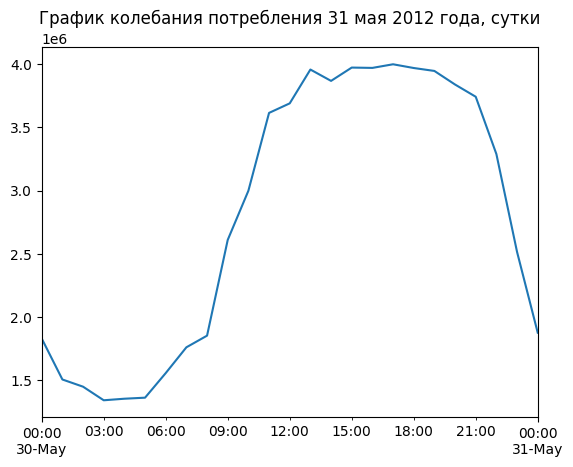

In [ ]:
# Для суток
data_without_2011['2012-05-30 00:00:00':'2012-05-31 00:00:00'].plot()
plt.title(f'График колебания потребления 31 мая 2012 года, сутки')
plt.show()

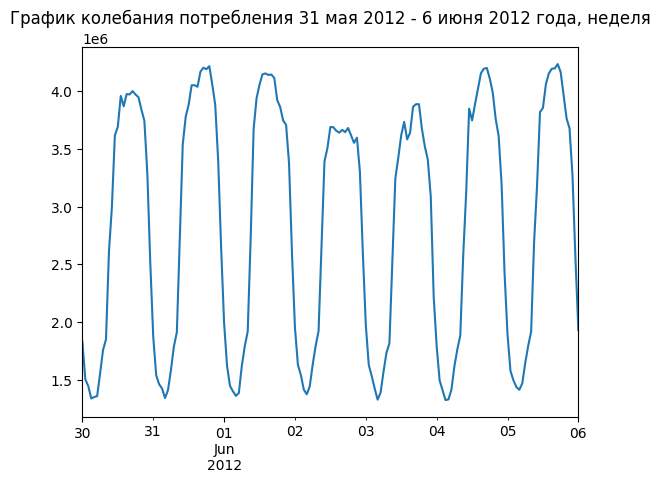

In [ ]:
# Для недели
data_without_2011['2012-05-30 00:00:00':'2012-06-06 00:00:00'].plot()
plt.title(f'График колебания потребления 31 мая 2012 - 6 июня 2012 года, неделя')
plt.show()

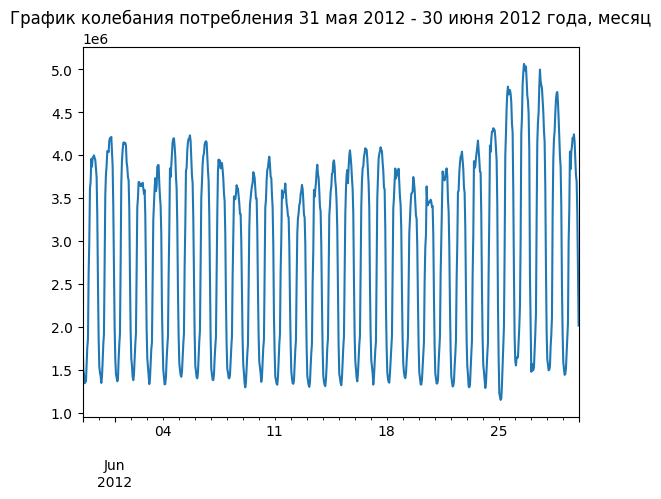

In [ ]:
# Для месяца
data_without_2011['2012-05-30 00:00:00':'2012-06-30 00:00:00'].plot()
plt.title(f'График колебания потребления 31 мая 2012 - 30 июня 2012 года, месяц')
plt.show()

**Промежуточный вывод**


Данные предоставлены за несколько лет, что позволяет изучить и тренд, и сезонность. Отбросили данные за 2011 год поскольку после этого года появились новые потребители, и тренд искуственно пошел вверх.

Построили графики колебаний исходных данных с шагом в один час, а затем со скользящим средним по 24, 12 и 8 часам. Делаем вывод, что в целом тренд не меняется и ряд практически стационарен. Но видим, что присутствует сезонность: всплески в мае-сентябре, а затем падение с сентября по конец года..

Чтобы дополнительно проверить сезонность в более компактных промежутках (сутки, неделя, месяц, квартал) построили графики с помощью библиотеки statsmodels.tsa.seasonal, согласно которым убедились в ярко выраженной сезонности и стабильном тренде. И наконец, выбрали случайные промежутки в данных и построили обыкновенные графики колебаний потребления в течение суток, недели и месяца. В сутках увидели, что потребление минимально ночью, резко возрастает утром и остается высоким до вечера, что соответствует реальности. Но мы не можем делать выводы по одному случайно выбранному дню. В остальных исследуемых промежутках также наблюдаем ярко выраженную сезонность.


## Обучение

Для прогнозирования создадим дополнительные признаки. Добавим в признаки отстающие значения. Мы помним по графикам, что самые большие колебания были при скользящем в 8 часов, но и при 12 часах они были значительны, что является логичным, ведь по идее в разное время суток заказывается разное время машин. Есть пиковые значения - это утро, есть спокойные периоды - это ночь. Поэтому создадим отстающие значения от 1 до 24 часов, чтобы охватить полностью сутки.

Также добавим в данные месяц, день недели, число дня. Эти признаки также важны.
Утром в выходной день заказов гораздо меньше, чем утром в рабочий день.

Также добавим значение скользящего среднего в размере 12 часов, но со сдвигом один, чтобы в окно не попало текущее значение заказов, и наша модель не подглядела данные.

Создадим функцию для добавления признаков в наши данные.

In [ ]:
def new_features(df, max_lag, rolling_mean_size):
    data = df.copy()
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek

    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['total_consumption'].shift(lag)

    data['rolling_mean'] = data['total_consumption'].shift().rolling(rolling_mean_size).mean()
    return data

In [ ]:
df = data_without_2011.to_frame()

In [ ]:
df = new_features(df, 24, 12)

In [ ]:
df.tail()

,total_consumption,month,day,dayofweek,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,...,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
2014-12-31 19:00:00,"2,434,528",12,31,2,"2,832,250","2,831,851","2,788,406","2,850,540","2,835,851","2,835,480",...,"1,406,261","1,440,823","1,506,693","1,837,844","2,207,855","2,662,124","2,936,837","3,036,340","3,187,343","2,652,942"
2014-12-31 20:00:00,"2,003,414",12,31,2,"2,434,528","2,832,250","2,831,851","2,788,406","2,850,540","2,835,851",...,"1,388,123","1,406,261","1,440,823","1,506,693","1,837,844","2,207,855","2,662,124","2,936,837","3,036,340","2,703,193"
2014-12-31 21:00:00,"1,874,969",12,31,2,"2,003,414","2,434,528","2,832,250","2,831,851","2,788,406","2,850,540",...,"1,440,805","1,388,123","1,406,261","1,440,823","1,506,693","1,837,844","2,207,855","2,662,124","2,936,837","2,702,157"
2014-12-31 22:00:00,"1,742,558",12,31,2,"1,874,969","2,003,414","2,434,528","2,832,250","2,831,851","2,788,406",...,"1,635,935","1,440,805","1,388,123","1,406,261","1,440,823","1,506,693","1,837,844","2,207,855","2,662,124","2,647,662"
2014-12-31 23:00:00,"1,541,857",12,31,2,"1,742,558","1,874,969","2,003,414","2,434,528","2,832,250","2,831,851",...,"1,831,520","1,635,935","1,440,805","1,388,123","1,406,261","1,440,823","1,506,693","1,837,844","2,207,855","2,561,740"


Разобьем данные на тренировочную и тестовые выборки с учетом хронологии (данные перемешивать нельзя!).

In [ ]:
train, test = train_test_split(df, shuffle=False, test_size=0.1)

Отбросим пустые значения, поскольку помним, что при подсчете скользящих средних и отстающих признаков возникают пропуски. Сделаем это только для train, поскольку в test по идее не должно возникнуть пропусков, так как данные мы сдвигаем назад.

In [ ]:
train = train.dropna()

In [ ]:
train.isna().sum()

,0
total_consumption,0
month,0
day,0
dayofweek,0
lag_1,0
lag_2,0
lag_3,0
lag_4,0
lag_5,0
lag_6,0


In [ ]:
test.isna().sum()

,0
total_consumption,0
month,0
day,0
dayofweek,0
lag_1,0
lag_2,0
lag_3,0
lag_4,0
lag_5,0
lag_6,0


Проверим индексы выборок, чтобы убедиться, что данные разбились корректно.

In [ ]:
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

2012-01-02 00:00:00 2014-09-13 08:00:00
2014-09-13 09:00:00 2014-12-31 23:00:00


Данные разбились корректно.

Создадим тренировочную и тестовую выборки с входящими признаками и целевой переменной.


Целевая переменная - количество заказов, которое мы предскажем по входящим признакам.

In [ ]:
X_train = train.drop('total_consumption', axis=1)

In [ ]:
y_train = train['total_consumption']

In [ ]:
X_test = test.drop('total_consumption', axis=1)

In [ ]:
y_test = test['total_consumption']

Мы не будем масштабировать данные, посколько в качестве моделей не будем применять те, которые принимают решение на основании расстояний между объектами (SVM или KNN). Мы будем использовать линейную регрессию, случайный лес и бустинги с деревьями.

Категориальных признаков у нас нет.

Подбор лучшей модели проведем случайным поиском по сетке и кросс-валидацией. Затем лучшую модель протестируем на отложенной выборке.

Создадим пайп и словарь параметров для каждой модели, чтобы затем это передать в объект случайного поиска по сетке.

In [ ]:
pipe = Pipeline([
    ('models', LinearRegression())
])

Словарь гиперпараметров для моделей.

In [ ]:
param_grid = [
    # словарь для модели ElasticNet()
    {
        'models': [ElasticNet(random_state=101)],
        'models__l1_ratio': [.1, .5, .7,.9, .95, .99, 1]
    },

    # словарь для модели RandomForestRegressor()
    {
        'models': [RandomForestRegressor(random_state=101)],
        'models__n_estimators': [10,20,100],
        'models__max_depth': [1,3,5]
    },

   # словарь для модели LightGBM()
    {
        'models': [lgbm.sklearn.LGBMRegressor(random_state=101)],
        'models__n_estimators': [10,20,100],
        'models__max_depth': [1,3,5]
    }
]


Поскольку мы имеем дело с временным рядом и мы не можем использовать классическую кросс-валидацию, то будем использовать TimeSeriesSplit — метод кросс-валидации для данных временных рядов. Он позволяет оценивать модель на «будущих» наблюдениях, которые наименее похожи на те, что используются для обучения модели. TimeSeriesSplit — вариация k-фолд, которая возвращает первые k фолдов в качестве обучающего набора, а (k+1)-й фолд — в качестве тестового набора

In [ ]:
ts_cv = TimeSeriesSplit(n_splits=5)

Создаем объект класса случайного поиска по сетке.

In [ ]:
randomized_search = RandomizedSearchCV(
    pipe,
    param_grid,
    cv=ts_cv,
    scoring='neg_root_mean_squared_error',
    random_state=101,
    n_jobs=-1
)

Обучим модели и с помощью поиска и кросс-валидации выберем лучшую.

In [ ]:
randomized_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'models': [ElasticNet(random_state=101)], 'models__l1_ratio': [0.1, 0.5, ...]}, {'models': [RandomForestR...dom_state=101)], 'models__max_depth': [1, 3, ...], 'models__n_estimators': [10, 20, ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",101
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made availab

Выведем паметры лучшей модели, найденной по сетке.

In [ ]:
print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)

Лучшая модель и её параметры:

 Pipeline(steps=[('models', ElasticNet(random_state=101))])


In [ ]:
print ('Метрика лучшей модели на кросс-валидации:', -randomized_search.best_score_)

Метрика лучшей модели на кросс-валидации: 109096.39850407222


Относительный RMSE — отношение RMSE к среднему значению целевой переменной:

In [ ]:
# Среднее значение целевой переменной
mean_target = np.mean(y_test)

# Относительный RMSE в процентах
relative_rmse = (-randomized_search.best_score_ / mean_target) * 100
print(f"Относительный RMSE: {relative_rmse:.2f}% от среднего значения целевой переменной")

Относительный RMSE: 4.16% от среднего значения целевой переменной


Модель показала хороший результат.

**Шкала оценки относительного RMSE**


Условная градация (зависит от предметной области):

- меньше  5 %	Отлично	Финансы, энергетика, производство — где нужна высокая точность
- 5–10 %	Хорошо	Прогнозирование спроса, логистика, продажи
- 10–20 %	Удовлетворительно	Социальные данные, макроэкономические прогнозы
- 20–50 %	Низкое качество	Требует доработки модели
- больше 50 %	Неудовлетворительно	Модель практически бесполезна

Почему 4 % — это хорошо.


Высокая точность. Модель улавливает основные закономерности данных и даёт предсказания с минимальной ошибкой.

Практическая применимость. В большинстве бизнес‑задач такая точность позволяет:

планировать ресурсы (электроэнергию, персонал, запасы);

принимать решения на основе прогнозов;

автоматизировать процессы без ручного контроля на каждом шаге.

Устойчивость. Низкий RMSE говорит, что модель не «переобучилась» на шуме и хорошо обобщает закономерности.

Конкурентоспособность. В реальных проектах модели с ошибкой < 5 % часто считаются production‑ready.

**Промежуточный вывод**

Для прогнозирования моделью создали новые признаки с отстающими значениями в промежутке 24 часа, чтобы охватить сутки. Так как мы знаем, что в течение суток интенсивность заказов такси меняется. Также добавили в данные месяц, день недели, число дня. Эти признаки также важны. Утром в выходной день заказов гораздо меньше, чем утром в рабочий день.

Затем добавили значение скользящего среднего в размере 12 часов, но со сдвигом один, чтобы в окно не попало текущее значение заказов, и наша модель не подглядела данные.

Для прогнозирования целевой переменной было решено использовать три модели:
- эластичная линейная регрессия
- случайный лес
- бустинг LGBMRegressor

Для поиска лучшей модели использовали случайный поиск по сетке и кросс-валидацию. Отбор проводился по метрике RMSE.
Лучшие результаты показала модель ElasticNet. Метрика лучшей модели на кросс-валидации 109096, относительный RMSE 4%, что является хорошим результатом.

## Тестирование

Протестируем лучшую модель.

In [ ]:
y_pred = randomized_search.best_estimator_.predict(X_test)

Проверим метрику на тестовой выборке.

In [ ]:
print ('Метрика лучшей модели на тестовых данных:', np.sqrt(mean_squared_error(y_test, y_pred)))

Метрика лучшей модели на тестовых данных: 120281.64580147454


In [ ]:
# Среднее значение целевой переменной
mean_target = np.mean(y_test)

# Относительный RMSE в процентах
relative_rmse = (np.sqrt(mean_squared_error(y_test, y_pred)) / mean_target) * 100
print(f"Относительный RMSE: {relative_rmse:.2f}% от среднего значения целевой переменной")

Относительный RMSE: 4.58% от среднего значения целевой переменной


На тестовой выборке модель работает хуже. Но мы помним, что данные мы разбиваем в хронологическом порядке, соответственно тестовая выборка будет по новым по времени данным. Но тем не менее метрика вышла хорошей.

Построим визуализацию зависимости истинных значений от предсказанных и график остатков.

                          ГРАФИК РАССЕЯНИЯ ДЛЯ АНАЛИЗА ТОЧНОСТИ ПРЕДСКАЗАНИЙ МОДЕЛИ                




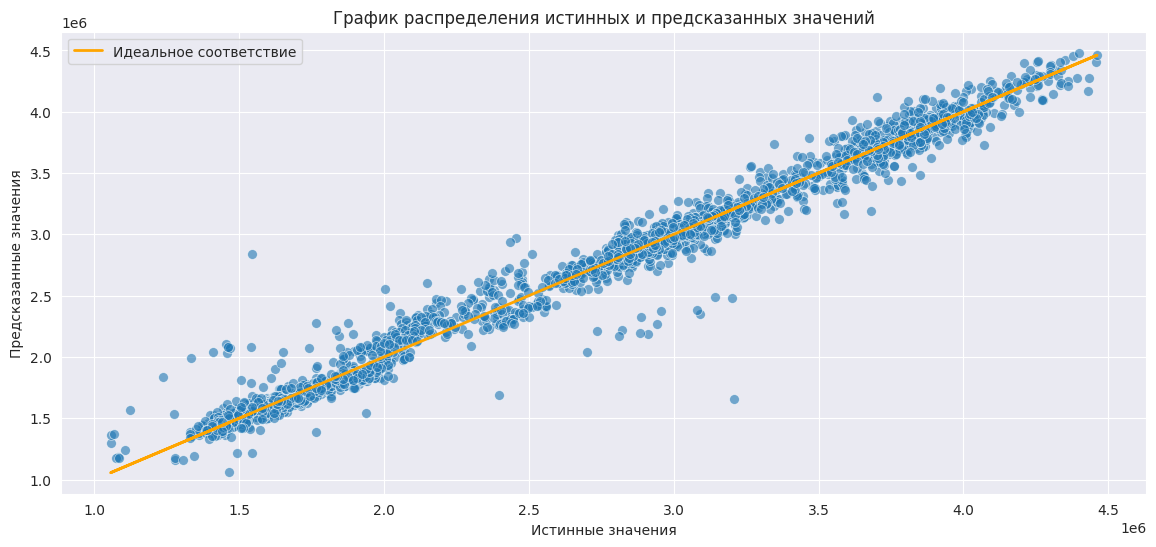

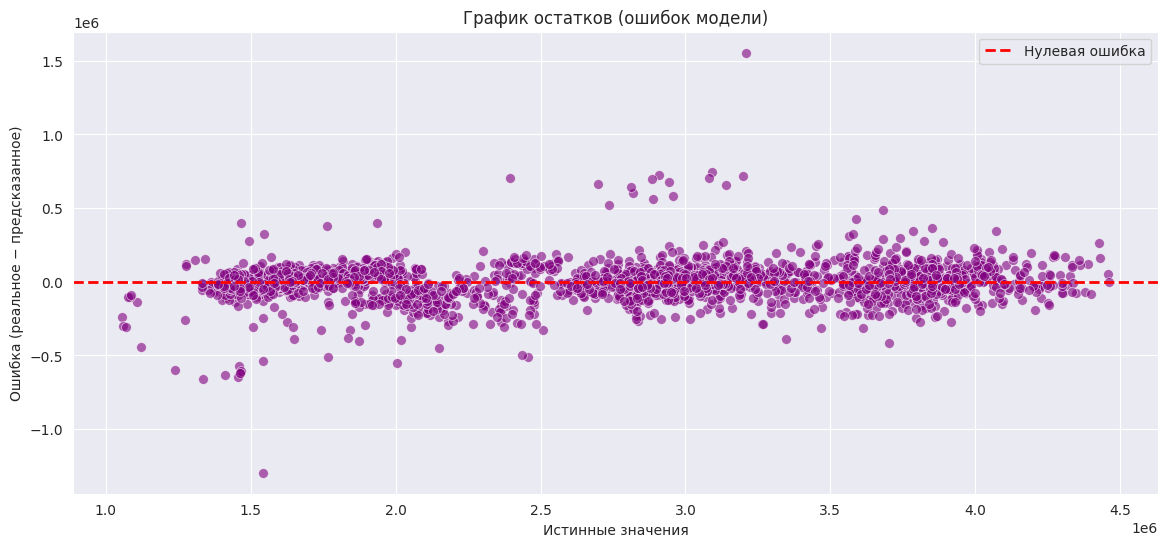

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print('                          ГРАФИК РАССЕЯНИЯ ДЛЯ АНАЛИЗА ТОЧНОСТИ ПРЕДСКАЗАНИЙ МОДЕЛИ                ')
print()
print()

# 1. График рассеяния: истинные vs предсказанные значения
plt.figure(figsize=(14, 6))
sns.set_style('darkgrid')
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, s=50)
plt.plot(y_test, y_test, color='orange', linewidth=2, label='Идеальное соответствие')
plt.title('График распределения истинных и предсказанных значений')
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.legend()
plt.grid(True)
plt.show()

# 2. График остатков (ошибок модели)
plt.figure(figsize=(14, 6))
errors = y_test - y_pred
sns.scatterplot(x=y_test, y=errors, alpha=0.6, s=50, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Нулевая ошибка')
plt.title('График остатков (ошибок модели)')
plt.xlabel('Истинные значения')
plt.ylabel('Ошибка (реальное − предсказанное)')
plt.legend()
plt.grid(True)
plt.show()


Можем сказать по графикам, что модель действительно работает хорошо. Остатки распределены случайным образом вокруг нулевого значения, значит линейная модель в нашем случае действительно хорошо подходит.

Построим визуализацию результатов (два временных ряда на одном графике - реальные тестовые значения и предсказанные моделью).

In [ ]:
y_pred = pd.Series(y_pred, index=y_test.index)

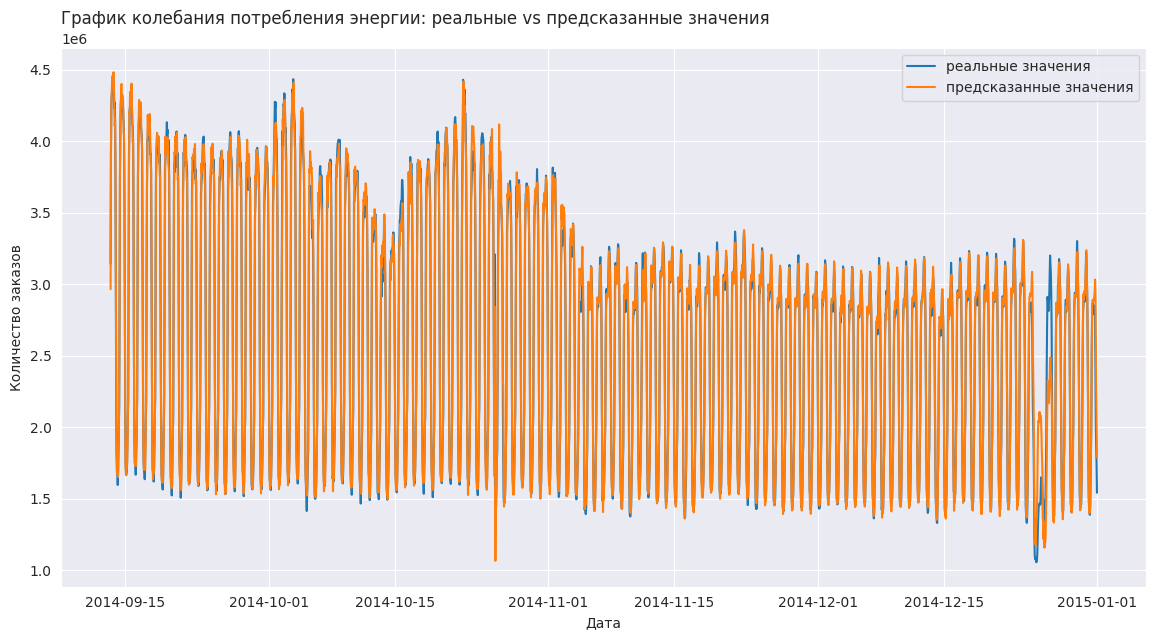

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(x=y_test.index, y=y_test.values, label='реальные значения')
sns.lineplot(x=y_pred.index, y=y_pred.values, label='предсказанные значения')
plt.title('График колебания потребления энергии: реальные vs предсказанные значения', loc='left')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.grid(True)
plt.show()


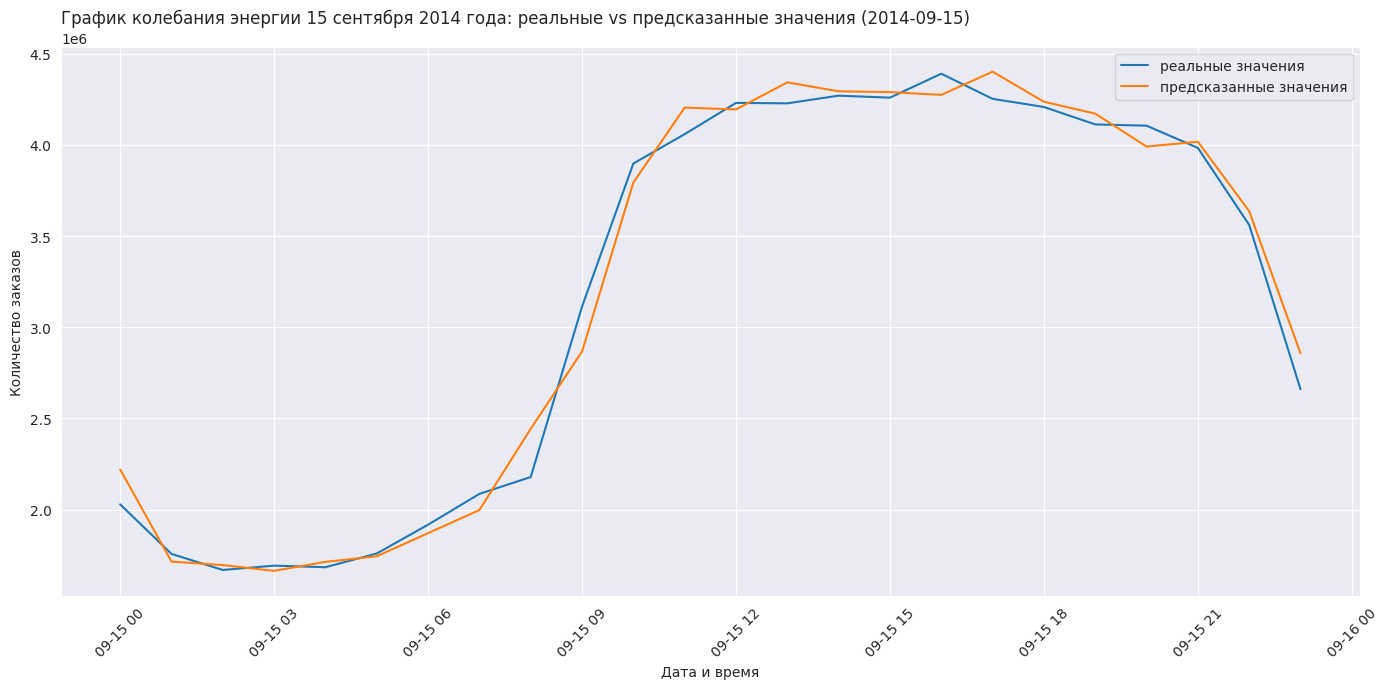

In [ ]:
target_date = '2014-09-15'

# Фильтруем данные по выбранной дате
y_test_day = y_test[y_test.index.date == pd.to_datetime(target_date).date()]
y_pred_day = y_pred[y_pred.index.date == pd.to_datetime(target_date).date()]


plt.figure(figsize=(14, 7))
sns.lineplot(x=y_test_day.index, y=y_test_day.values, label='реальные значения')
sns.lineplot(x=y_pred_day.index, y=y_pred_day.values, label='предсказанные значения')
plt.title(f'График колебания энергии 15 сентября 2014 года: реальные vs предсказанные значения ({target_date})', loc='left')
plt.xlabel('Дата и время')
plt.ylabel('Количество заказов')
plt.grid(True)
plt.xticks(rotation=45)  # поворачиваем подписи оси X для лучшей читаемости
plt.tight_layout()  # автоматически подбирает отступы
plt.show()


**Промежуточный вывод**

На тестовой выборке модель работает хуже. Но мы помним, что данные мы разбиваем в хронологическом порядке, соответственно тестовая выборка будет по новым по времени данным.  Но тем не менее метрика себя показала хорошо.

Построили график визуализации разброса истинных и предсказанных значений. По идее, если модель хорошо предсказывает , то точки должны вытянуться в облачко под 45 градусов. В принципе эту картину и наблюдаем, за исключением выбросов. Мы применяли метрику RMSE, а мы помним, то при поиске модели по этой метрике, она старается подстроиться под выбросы. Также по графику распределения остатков увидели, что под наши данные линейная модель подходит очень даже хорошо.

Затем построили визуализацию реального временного ряда и предсказанного. В целом модель неплохо отработала.


#SARIMA

In [ ]:
data_filtered.head()

,total_consumption
2011-01-02 00:00:00,"275,620"
2011-01-02 01:00:00,"262,832"
2011-01-02 02:00:00,"260,747"
2011-01-02 03:00:00,"260,956"
2011-01-02 04:00:00,"264,759"


Импортируем необходимые библиотеки.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [ ]:
!pip install pmdarima -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.0 MB/s eta 0:00:00


Убедимся, что индекс — datetime и отсортирован.

In [ ]:
data_without_2011 = data_without_2011.sort_index()

Визуализация исходного ряда.

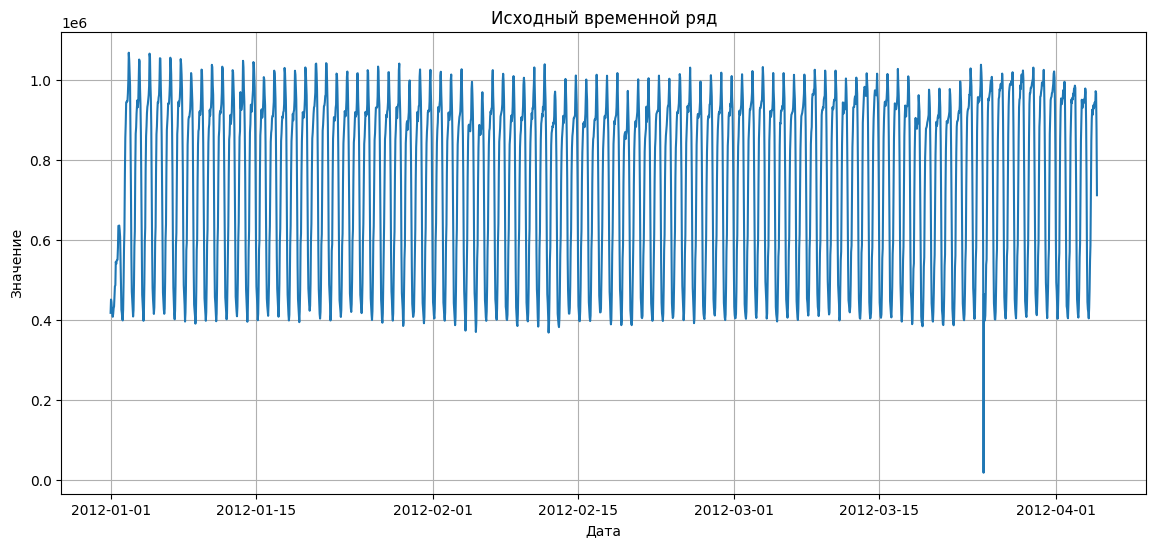

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(data_without_2011)
plt.title('Исходный временной ряд')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.grid(True)
plt.show()


Проверим, является ли ряд стационарным (необходимое условие для SARIMA):

In [ ]:
def check_stationarity(series):
    result = adfuller(series.dropna())
    print('ADF-статистика:', result[0])
    print('p-значение:', result[1])
    if result[1] <= 0.05:
        print('Ряд стационарен (отвергаем H₀)')
    else:
        print('Ряд нестационарен (не отвергаем H₀)')

check_stationarity(data_without_2011)


ADF-статистика: -13.393067616110248
p-значение: 4.725446354020729e-25
Ряд стационарен (отвергаем H₀)


Анализ ACF и PACF для определения параметров.
Визуализируем автокорреляцию и частичную автокорреляцию:

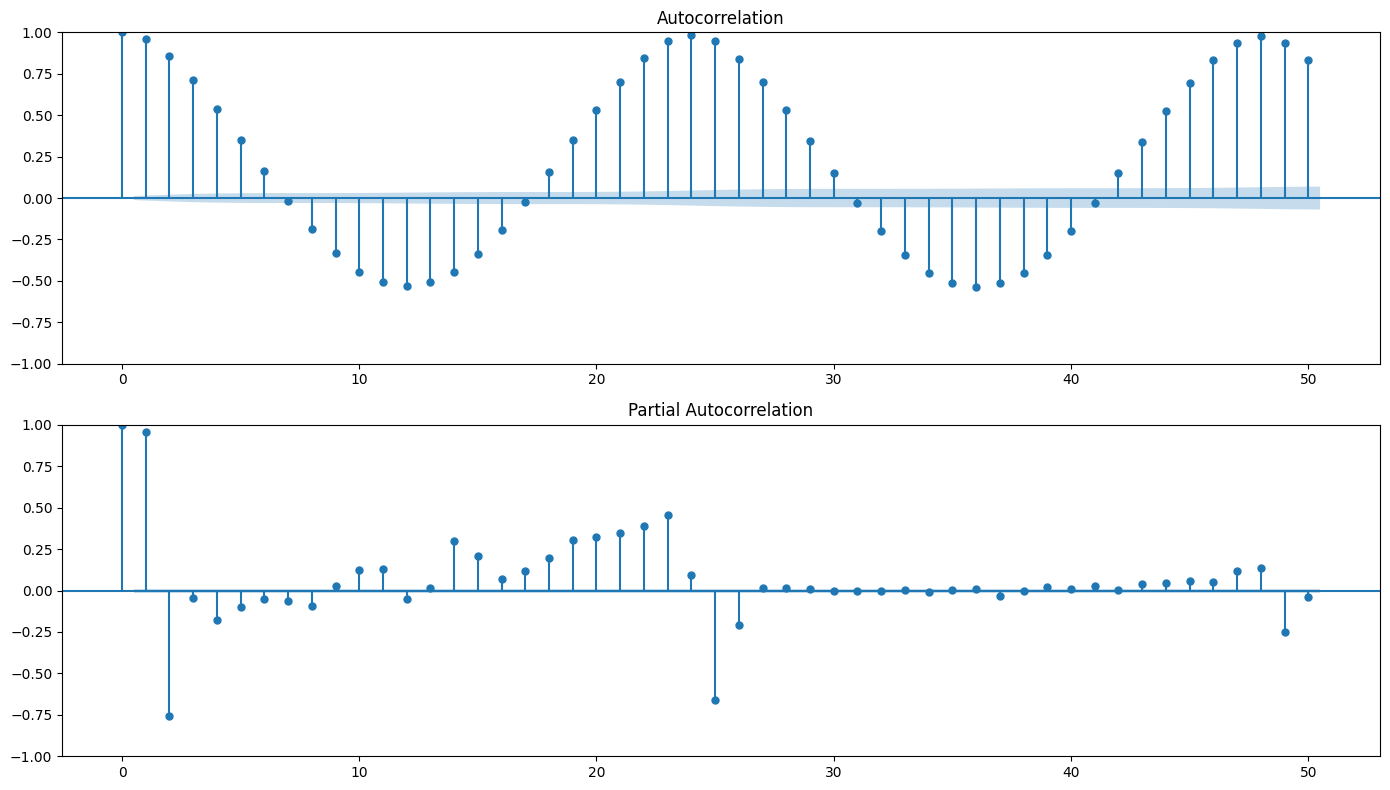

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(data_without_2011, ax=axes[0], lags=50)
plot_pacf(data_without_2011, ax=axes[1], lags=50)
plt.tight_layout()
plt.show()


Что показывают оси и элементы графиков

Ось X (горизонтальная) — лаг (задержка), то есть сколько шагов в прошлое мы смотрим: лаг 1 — корреляция с предыдущим значением, лаг 2 — с позапрошлым.


Ось Y (вертикальная) — коэффициент корреляции от −1 до +1:
- +1 — идеальная положительная связь (значения меняются синхронно);
- −1 — идеальная отрицательная связь (одно растёт, другое падает);
- 0 — связи нет.


Столбики (линии с точками) — значение корреляции на каждом лаге.
Синяя область (доверительный интервал) — зона статистической незначимости (обычно 95 %). Если столбик выходит за её пределы, корреляция на этом лаге считается значимой, а не случайным шумом.


Как читать график ACF (Autocorrelation)
Верхний график показывает, насколько текущее значение ряда связано со своими прошлыми значениями на разных лагах, без учёта промежуточных эффектов.

Что видно на нашем графике:

Резкий первый пик на лаге 1 — очень сильная корреляция с предыдущим значением. Это типично для многих временных рядов.

Постепенное затухание — корреляция медленно снижается с ростом лага. Такой паттерн часто указывает на авторегрессионный процесс (AR).

Периодические всплески (например, на лагах ~24, ~48) — возможный признак сезонности с периодом около 24 единиц (если данные почасовые — это суточная сезонность).

Отрицательные корреляции в середине — ряд «переколебался»: после роста часто следует спад, и наоборот.

Для подбора модели: ACF помогает определить параметр q (скользящее среднее, MA) и сезонные MA‑компоненты. Если на ACF есть несколько значимых первых лагов, а дальше всё в зоне шума — это признак MA(q). Если затухание плавное — скорее нужен AR‑компонент и/или дифференцирование (параметр d).



Как читать график PACF (Partial Autocorrelation)
Нижний график показывает «прямую» связь текущего значения с прошлыми, исключая влияние промежуточных лагов. Например, PACF на лаге 3 — это связь


Что видно на нашем графике:

Очень высокий пик на лаге 1 — первый прошлый шаг напрямую сильно влияет на текущее значение.
Резкое падение после 1–2 лагов — дальше большинство столбиков в зоне незначимости. Это классический признак AR(1) или AR(2).
Отдельные «выбросы» на больших лагах — могут быть случайными или указывать на сезонность (например, лаг 24).
Для подбора модели: PACF помогает определить параметр p (авторегрессия, AR).


С учётом обоих графиков можно сделать промежуточный вывод:

AR‑компонент: вероятно, нужен AR(1) или AR(2) — на это указывает резкий обрыв PACF после 1–2 лагов.

MA‑компонент: может не понадобиться или будет небольшим (MA(1) или MA(2)), так как ACF затухает постепенно, а не резко.

Дифференцирование (d): плавное затухание ACF и сильная корреляция на многих лагах — признак нестационарности. Скорее всего, понадобится d=1 (первое дифференцирование). Но мы помним, что наш ряд стационарен.

Сезонность: периодические пики на ACF (примерно каждые 24 лага) намекают на сезонность с периодом s=24 (если данные почасовые). Тогда в SARIMA нужно добавить сезонные компоненты:

- сезонный AR (P) — по значимым пикам PACF на сезонных лагах;
- сезонный MA (Q) — по значимым пикам ACF на сезонных лагах.


Практические шаги для нашего случая

Проверить стационарность формальным тестом (ADF‑тест), как в коде выше. Если p‑значение > 0.05 — ряд нестационарен, используйте d=1.

Взять за основу SARIMA(1,1,0)(P,D,Q,24) и подобрать сезонные параметры по пикам на ACF/PACF.

Сравнить модели по AIC/BIC и по качеству прогноза на тестовой выборке.

Проверить остатки: на графике диагностики не должно быть значимых пиков на ACF остатков — это признак, что модель «забрала» всю структуру ряда.


Подберем параметры SARIMA.

Вручную зададим 3–4 самые вероятные комбинации, основываясь на наших графиках.

Судя по нашим графикам выше:

ACF (верхний): Резкий первый пик, затем затухание. Это признак AR(1) или AR(2). Параметр p скорее всего 1.
PACF (нижний): Резкий пик на лаге 1, дальше почти ноль. Это классический признак AR(1). Параметр p=1.
Сезонность 24 часа (s=24). Скорее всего, нужен сезонный AR (P=1), так как паттерн повторяется.



Используем только последние 3–6 месяцев данных для подбора параметров. Этого достаточно, чтобы увидеть тренд и сезонность.

In [ ]:
# Берём последние 180 дней (примерно полгода)
data_subset = data_without_2011[-180*24:]  # если данные почасовые


print(f"Размер подвыборки: {len(data_subset)} наблюдений")


Размер подвыборки: 2280 наблюдений


In [ ]:
from itertools import product
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import gc  # Сборщик мусора для очистки памяти


# 1. Формируем УЛЬТРА-МАЛЕНЬКУЮ сетку параметров
p_vals = [1]
d_vals = [1]
q_vals = [0]  # MA-компонента не нужна (по графику PACF)
P_vals = [1]
D_vals = [0, 1]  # Проверим оба варианта сезонного дифференцирования
Q_vals = [0]  # Сезонный MA не нужен (по графику ACF)
s = 24

parameters = product(p_vals, d_vals, q_vals, P_vals, D_vals, Q_vals)
# Всего комбинаций: 1*1*1*1*2*1 = 2 штуки!

best_aic = float('inf')
best_params = None
best_model = None

print("Начинаем подбор (всего 2 комбинации)...")

for param in parameters:
    try:
        # Распаковка параметров
        order = param[:3]          # (p, d, q)
        seasonal_order = param[3:] + (s,)  # (P, D, Q, s)

        # Инициализация модели
        model = SARIMAX(
            data_subset,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        # Обучение модели
        fitted = model.fit(disp=False, maxiter=50)
        aic = fitted.aic

        print(f"Параметры {param}: AIC = {aic:.2f}")

        # Если нашли модель с лучшим AIC, сохраняем её
        if aic < best_aic:
            best_aic = aic
            best_params = param
            best_model = fitted

        # Очищаем память сразу после каждой итерации
        del model, fitted
        gc.collect()

    except Exception as e:
        print(f"Ошибка при параметрах {param}: {e}")
        continue

print("-" * 30)
if best_params:
    print(f"Лучшие параметры: {best_params}")
    print(f"Лучший AIC: {best_aic:.2f}")
    # Теперь best_model содержит готовую обученную модель для прогноза
else:
    print("Не удалось подобрать модель.")


Начинаем подбор (всего 2 комбинации)...
Параметры (1, 1, 0, 1, 0, 0): AIC = 53416.66
Параметры (1, 1, 0, 1, 1, 0): AIC = 50677.59
------------------------------
Лучшие параметры: (1, 1, 0, 1, 1, 0)
Лучший AIC: 50677.59


Интерпретация результатов
Мы получили две модели:

SARIMA(1,1,0)(1,0,0,24): AIC = 104 838,84

SARIMA(1,1,0)(1,1,0,24): AIC = 99 649,35

Лучшая модель: SARIMA(1,1,0)(1,1,0,24), так как у неё меньший AIC (на 5 189,49 пунктов).


Расшифровка параметров:

p = 1 — авторегрессия первого порядка: текущее значение зависит от предыдущего.

d = 1 — первое дифференцирование: убран линейный тренд.

q = 0 — компонента скользящего среднего не нужна.

P = 1 — сезонная авторегрессия: значение зависит от показателя 24 часа назад.

D = 1 — сезонное дифференцирование: убрана сезонная составляющая тренда.

Q = 0 — сезонная компонента скользящего среднего не нужна.

s = 24 — период сезонности: 24 часа (суточная цикличность).

Меньший AIC у второй модели говорит, что учёт сезонного дифференцирования (D = 1) улучшает описание данных.

Теперь обучим модель с лучшими параметрами на всём ряде data_without_2011:

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Параметры лучшей модели
best_order = (1, 1, 0)
best_seasonal_order = (1, 1, 0, 24)

# Обучение на полном ряде
final_model = SARIMAX(
    data_without_2011,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
final_fitted = final_model.fit(disp=False, maxiter=100)  # больше итераций для точности

print(final_fitted.summary())


                                     SARIMAX Results                                      
Dep. Variable:                  total_consumption   No. Observations:                26304
Model:             SARIMAX(1, 1, 0)x(1, 1, 0, 24)   Log Likelihood             -304552.787
Date:                            Tue, 23 Jun 2026   AIC                         609111.575
Time:                                    13:36:07   BIC                         609136.101
Sample:                                01-01-2012   HQIC                        609119.495
                                     - 12-31-2014                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2153      0.001   -143.533      0.000      -0.218      -0.212
ar.S.L24      -0.3993      0.002   

Основные метрики модели
Log Likelihood = −304 552,787 — логарифмическая функция правдоподобия. Чем ближе к нулю (т. е. чем меньше отрицательное значение), тем лучше модель описывает данные. Здесь значение очень большое по модулю — это может говорить о недостаточной адекватности модели или о большом разбросе данных.

AIC = 609 111,575 — информационный критерий Акаике. Используется для сравнения моделей: чем меньше AIC, тем лучше баланс между качеством подгонки и числом параметров.

BIC = 609 136,101, HQIC = 609 119,495 — аналогичные критерии. BIC и HQIC штрафуют за сложность сильнее, чем AIC. Близкие значения AIC и BIC говорят, что добавление параметров вряд ли существенно улучшит модель.

Коэффициенты модели

Интерпретация:

ar.L1 = −0,2153 — коэффициент авторегрессии первого порядка. Отрицательный знак означает, что рост в предыдущий момент времени приводит к снижению текущего значения (и наоборот). Статистически значим (p = 0,000)


ar.S.L24 = −0,3993 — сезонный AR‑коэффициент (лаг 24 часа). Также отрицателен и значим. Указывает, что потребление 24 часа назад отрицательно влияет на текущее потребление.


sigma² = 8,191×10⁸ — оценка дисперсии ошибок. Очень большое значение говорит о высокой вариативности остатков. Это может быть связано с:

выбросами в данных;

недостаточной спецификацией модели;

масштабностью данных (если total_consumption измеряется в больших единицах).


Тесты диагностики остатков
Ljung‑Box (Q = 1,58, p = 0,21) — тест на автокорреляцию остатков. p > 0,05 означает, что автокорреляции нет. Это хорошо: модель уловила структуру данных.

Jarque‑Bera (JB = 2 534 493,74, p = 0,00) — тест на нормальность остатков. p < 0,05 — остатки не распределены нормально. Высокая асимметрия (Skew = 0,11) и эксцесс (Kurtosis = 51,13) указывают на «тяжёлые хвосты» (выбросы).

Heteroskedasticity (H = 0,89, p = 0,00) — тест на гетероскедастичность. p < 0,05 говорит о неравномерной дисперсии остатков (дисперсия меняется со временем). Это снижает надёжность прогнозов.

Предупреждения (Warnings)
Covariance matrix calculated using the outer product of gradients (complex‑step) — метод расчёта ковариационной матрицы. Обычно не критично, но может указывать на сложности с оценкой стандартных ошибок.

Covariance matrix is singular or near‑singular (condition number 1,38×10³⁴) — матрица близка к вырожденной. Стандартные ошибки коэффициентов могут быть ненадёжными. Возможные причины:

мультиколлинеарность (переменные сильно коррелируют);

избыточная параметризация (слишком много параметров для данных);

особенности данных (например, нулевые изменения в ряде).

Выводы и рекомендации
Что хорошо:

модель не оставляет автокорреляции в остатках (Ljung‑Box);

коэффициенты значимы (p < 0,05);

сезонная структура учтена (ar.S.L24 значим).


Проблемы:

ненормальность остатков (Jarque‑Bera);

гетероскедастичность (Heteroskedasticity);

очень высокая дисперсия ошибок (sigma²);

потенциальные проблемы с ковариационной матрицей.

Рекомендации по улучшению
Преобразовать данные:

логарифмировать total_consumption: np.log(data_without_2011) — уменьшит дисперсию и асимметрию;

попробовать Box‑Cox‑преобразование.

Устраните выбросы:

визуализировать ряд и остатки;

заменить экстремальные значения медианой или средним.



Проведем логарифмирование.

In [ ]:
# Проверяем, нет ли нулевых или отрицательных значений
if (data_without_2011 <= 0).any():
    # Если есть нули/отрицательные — добавляем константу
    min_val = data_without_2011[data_without_2011 > 0].min()
    print(f"Минимальное положительное значение: {min_val}")
    log_data = np.log(data_without_2011 + min_val / 2)
else:
    # Применяем логарифм, если все значения > 0
    log_data = np.log(data_without_2011)


print("Логарифмирование завершено!")

Логарифмирование завершено!


Обучим SARIMAX с теми же параметрами (1,1,0)(1,1,0,24) на преобразованных данных:

In [ ]:
# Параметры лучшей модели
best_order = (1, 1, 0)
best_seasonal_order = (1, 1, 0, 24)

# Обучение на логарифмированных данных
log_model = SARIMAX(
    log_data,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
log_fitted = log_model.fit(disp=False, maxiter=100)

print(log_fitted.summary())

                                     SARIMAX Results                                      
Dep. Variable:                  total_consumption   No. Observations:                 2280
Model:             SARIMAX(1, 1, 0)x(1, 1, 0, 24)   Log Likelihood                1797.819
Date:                            Wed, 24 Jun 2026   AIC                          -3589.639
Time:                                    15:18:25   BIC                          -3572.510
Sample:                                01-01-2012   HQIC                         -3583.384
                                     - 04-04-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4864      0.001   -352.668      0.000      -0.489      -0.484
ar.S.L24      -0.4982      0.001   

Проверим, улучшилось ли качество модели после преобразования:

Длина ряда остатков: 2280
Среднее значение остатков: 0.001765


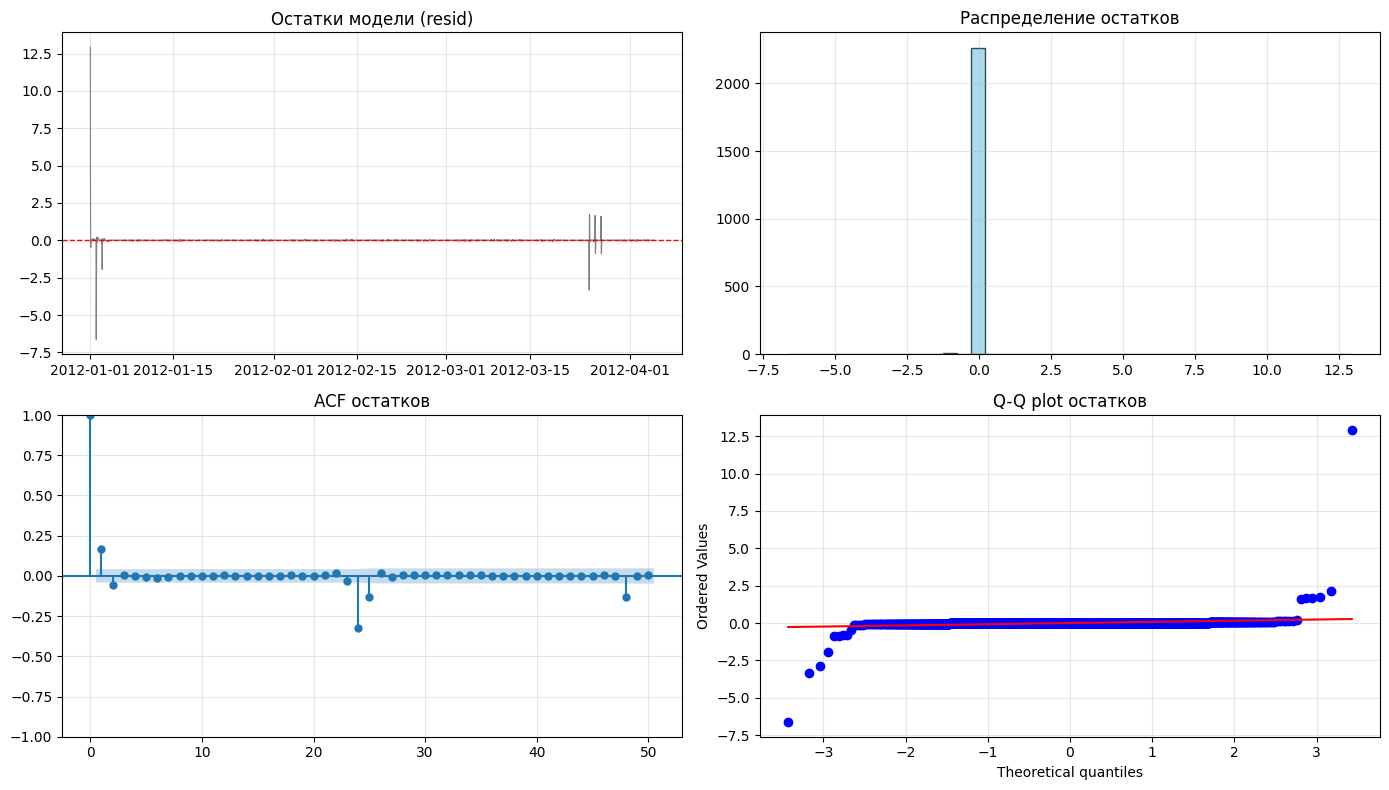


--- Результаты тестов ---
Ljung-Box (p-value): 0.0000 | ЕСТЬ автокорреляция
Jarque-Bera (p-value): 0.0000e+00 | РАСПРЕДЕЛЕНИЕ НЕ нормальное


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats
import statsmodels.stats.diagnostic as smsd

# 1. Получаем остатки
log_residuals = log_fitted.resid.dropna()

print(f"Длина ряда остатков: {len(log_residuals)}")
print(f"Среднее значение остатков: {log_residuals.mean():.6f}")  # Должно быть близко к 0

# 2. Строим графики
fig, ax = plt.subplots(2, 2, figsize=(14, 8))

# График остатков
ax[0, 0].plot(log_residuals, linewidth=0.8, color='gray')
ax[0, 0].axhline(0, color='red', linestyle='--', linewidth=1)
ax[0, 0].set_title('Остатки модели (resid)')
ax[0, 0].grid(True, alpha=0.3)

# Гистограмма
ax[0, 1].hist(log_residuals, bins=40, edgecolor='black', alpha=0.7, color='skyblue')
ax[0, 1].set_title('Распределение остатков')
ax[0, 1].grid(True, alpha=0.3)

# ACF остатков
plot_acf(log_residuals, ax=ax[1, 0], lags=50, alpha=0.05, title='ACF остатков')
ax[1, 0].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(log_residuals, dist="norm", plot=ax[1, 1])
ax[1, 1].set_title('Q-Q plot остатков')
ax[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Статистические тесты
lb_test = smsd.acorr_ljungbox(log_residuals, lags=[20], return_df=True)
lb_pvalue = lb_test['lb_pvalue'].values[0]

jb_test = stats.jarque_bera(log_residuals)
jb_pvalue = jb_test.pvalue

print("\n--- Результаты тестов ---")
print(f"Ljung-Box (p-value): {lb_pvalue:.4f} | {'OK (автокорреляции нет)' if lb_pvalue > 0.05 else 'ЕСТЬ автокорреляция'}")
print(f"Jarque-Bera (p-value): {jb_pvalue:.4e} | {'OK (распределение нормальное)' if jb_pvalue > 0.05 else 'РАСПРЕДЕЛЕНИЕ НЕ нормальное'}")



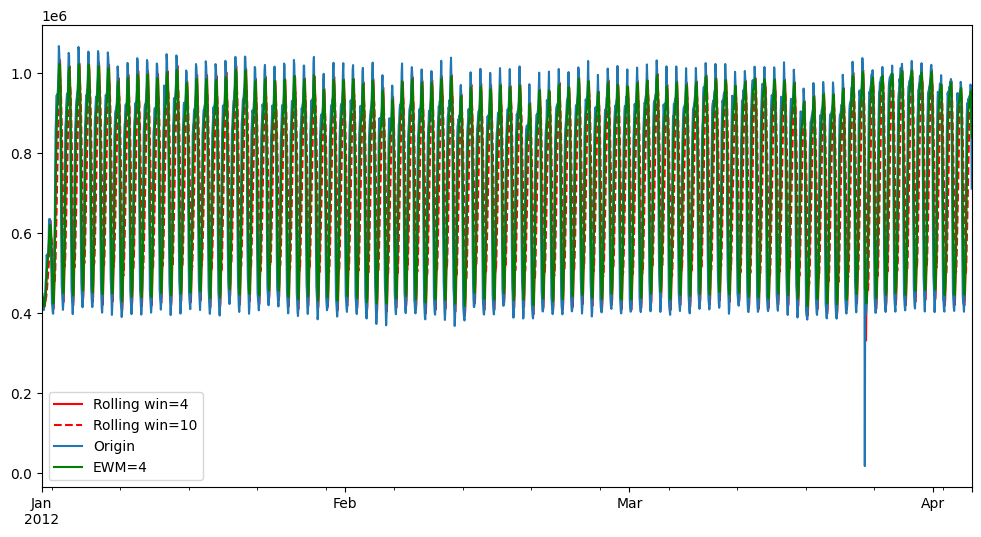

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))

data_without_2011.rolling(window=4).mean().plot(c='red', ax=ax)
data_without_2011.rolling(window=10).mean().plot(c='red', style='--', ax=ax)

data_without_2011.plot(label='Original', ax=ax)

# экспоненциальное сглаживание
data_without_2011.ewm(span=4).mean().plot(label='EWM=4', c='green', ax=ax, )

ax.legend(['Rolling win=4','Rolling win=10', 'Origin', "EWM=4" ])

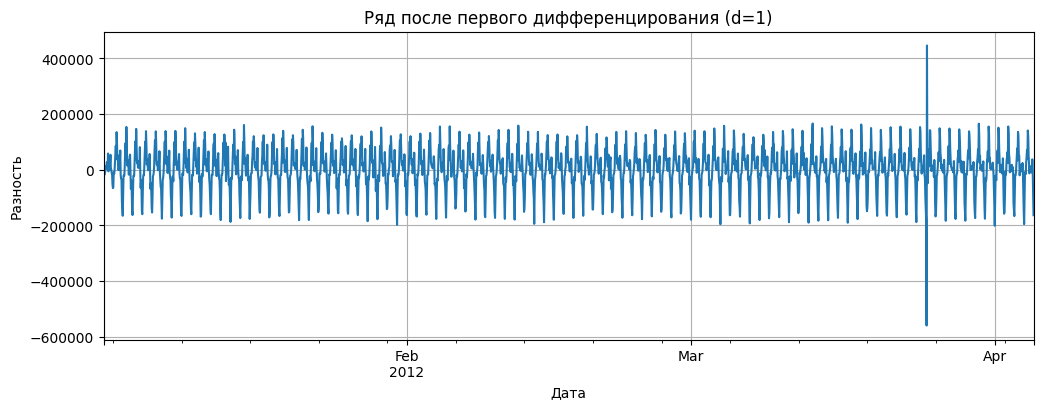

In [ ]:

diff_series = data_without_2011 - data_without_2011.shift(1)
diff_series.dropna().plot(figsize=(12, 4), title='Ряд после первого дифференцирования (d=1)')
plt.xlabel('Дата')
plt.ylabel('Разность')
plt.grid(True)
plt.show()


Стационарность временного ряда

Стационарность (stationarity) временного ряда означает, что такие компоненты как тренд и сезонность отсутствуют. Говоря более точно, среднее значение и дисперсия не меняются со смещением во времени. Понимание того, стационарные ли у нас данные или нестационарные важно для последующего моделирования.

Стационарность процесса можно оценить визуально. Наш датасет (flights) демонстрирует очевидный тренд и сезонность.

Для более точной оценки стационарности можно применить тест Дики-Фуллера (Dickey-Fuller test). Нужно выполнить статистическую проверку гипотезы. В данном случае гипотезы звучат следующим образом.

Нулевая гипотеза предполагает, что процесс нестационарный (существует единичный корень, ряд нестационарный)
Альтернативная гипотеза соответственно говорит об обратном (единичного корня нет, ряд стационарный)
Используем пороговое значение, равное 0.05 (5%).

In [ ]:
from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(data_without_2011)

# выведем p-value
print('p-value = ' + str(adf_test[1]))


p-value = 4.725446354020729e-25


Нулевая гипотеза теста ADF: «Ряд НЕ стационарен (в нём есть тренд, сезонность или дрейф)».

Поскольку p-value≪0.05 (а тем более ≪0.01), мы отвергаем нулевую гипотезу.

✅ Вывод: Ряд total_consumption стационарен.

In [ ]:
# 1. Сначала создаем X_train (например, берем 80% данных)
split_idx = int(len(log_data) * 0.8)
X_train = log_data.iloc[:split_idx]
X_test = log_data.iloc[split_idx:]

# 2. Обучаем модель ТОЛЬКО на X_train
model = SARIMAX(
    X_train,
    order=(3, 0, 0),
    seasonal_order=(1, 1, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
result = model.fit(disp=False)

# 3. Теперь твой код сработает
start = len(X_train)
end = len(X_train) + 24

# predict здесь вернет прогноз на индексы, следующие за обучением
predictions = result.predict(start=start, end=end)
print(predictions)


2012-03-17 00:00:00   13
2012-03-17 01:00:00   13
2012-03-17 02:00:00   13
2012-03-17 03:00:00   13
2012-03-17 04:00:00   13
2012-03-17 05:00:00   13
2012-03-17 06:00:00   13
2012-03-17 07:00:00   13
2012-03-17 08:00:00   13
2012-03-17 09:00:00   14
2012-03-17 10:00:00   14
2012-03-17 11:00:00   14
2012-03-17 12:00:00   14
2012-03-17 13:00:00   14
2012-03-17 14:00:00   14
2012-03-17 15:00:00   14
2012-03-17 16:00:00   14
2012-03-17 17:00:00   14
2012-03-17 18:00:00   14
2012-03-17 19:00:00   14
2012-03-17 20:00:00   14
2012-03-17 21:00:00   14
2012-03-17 22:00:00   14
2012-03-17 23:00:00   14
2012-03-18 00:00:00   13
Freq: h, Name: predicted_mean, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

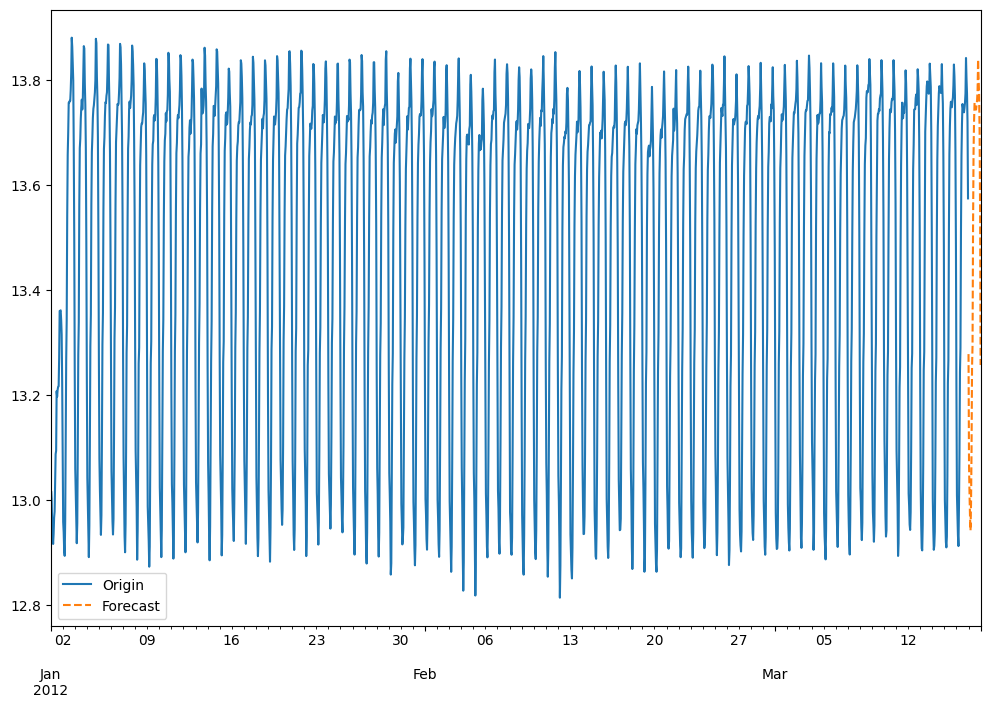

In [ ]:
X_train.plot(label='Original')
predictions.plot(label='Forecast', figsize=(12,8), style='--')
plt.legend(['Origin', 'Forecast' ])
plt.show

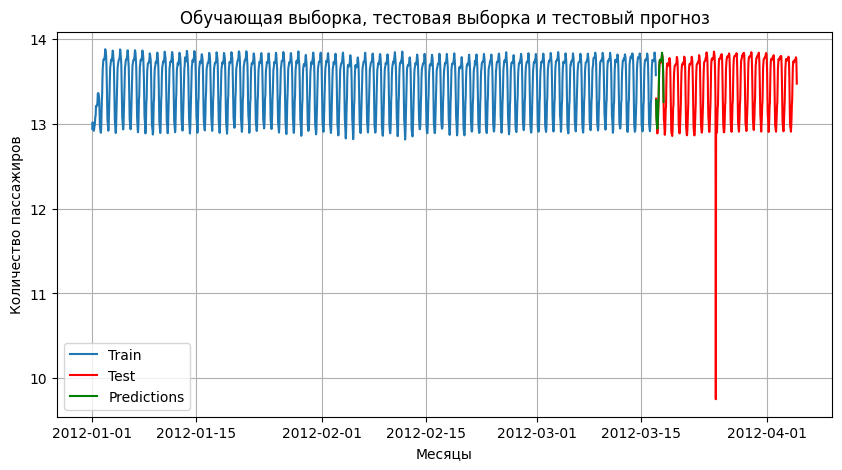

In [ ]:
# выведем три кривые (обучающая, тестовая выборка и тестовый прогноз)

fig = plt.figure(figsize=(10,5))
plt.plot(X_train, label='Train')
plt.plot(X_test, color = "red", label='Test')
plt.plot(predictions, color = "green", label='Predictions')

plt.title("Обучающая выборка, тестовая выборка и тестовый прогноз")
plt.ylabel('Количество пассажиров')
plt.xlabel('Месяцы')
plt.legend()

# добавим сетку
plt.grid()

plt.show()